# Detecção de Fraude em Transações com GNNs — Notebook Reprodutível (v4 • clean)

Este notebook consolida (em um único fluxo executável) os ajustes de rigor metodológico solicitados:

- **Setting temporal vs. transdutivo**: opção explícita e correção de *leakage* (estrutura e features).
- **Baselines não‑GNN**: **MLP (sem message passing)** + **XGBoost/LightGBM** (opcionais).
- **Capacidade comparável**: relatório de **parâmetros treináveis** e suporte a *equalização* por `hidden_dim`.
- **Early stopping alinhado**: monitoramento por **AP** e/ou **Recall@k%**.
- **Avaliação por limiar sem vazamento**: limiar **selecionado na validação** e aplicado no teste.
- **“Pureza” de casos/grupos**: substitui P@k(grupos) por métricas de **pureza/contaminação** consistentes.
- **Custo real**: tempo e memória por etapa (pré‑processamento, treino e inferência).

> Recomendação: execute as células em ordem. As seções “sweep” (profundidade/hyperparam/seed) são opcionais.


## Configurações de experimento

**Escolha o setting (importante para a banca):**

- `SETTING = "temporal"`: avaliação *realista* (sem usar arestas futuras na message passing; features agregadas só do histórico permitido).
- `SETTING = "transductive"`: assume grafo estático completo conhecido (permite usar a estrutura inteira na message passing). Ainda assim, **o scaler é ajustado no treino**.

**Observação sobre profundidade (100 camadas):** é possível testar, mas em GNNs “clássicas” isso costuma causar *oversmoothing/oversquashing* e piorar (ou explodir custo). No final há um *sweep* opcional com residual + LayerNorm para você testar de forma defensável.


In [1]:
# Instalação mínima (funciona mesmo sem wheels extras)
!pip -q install torch_geometric

import torch
import torch_geometric

print("torch:", torch.__version__)
print("cuda :", torch.version.cuda)
print("pyg  :", torch_geometric.__version__)

torch: 2.9.0+cu126
cuda : 12.6
pyg  : 2.7.0


In [2]:
## %% [1] Setup: dependências, GPU/CPU e diretórios do projeto
import os, sys, re, subprocess
from pathlib import Path

def pip_install(pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q"] + pkgs)

# Dependências gerais
pip_install(["numpy","pandas","scikit-learn","matplotlib","networkx","psutil","tqdm"])

# PyTorch (normalmente já vem no Colab). Se não vier, instale aqui.
try:
    import torch
except Exception:
    # Ajuste o index-url se você estiver fora do Colab ou com outra CUDA.
    pip_install(["torch","torchvision","torchaudio","--index-url","https://download.pytorch.org/whl/cu121"])
    import torch

# PyG: instala wheels compatíveis com torch/cuda (evita compilar do source)
try:
    import torch_geometric  # noqa: F401
except Exception:
    torch_ver = torch.__version__.split("+")[0]
    cuda_ver  = torch.version.cuda  # ex: '12.1' ou None
    if cuda_ver is None:
        cu_tag = "cpu"
    else:
        m = re.match(r"(\d+)\.(\d+)", cuda_ver)
        cu_tag = f"cu{m.group(1)}{m.group(2)}" if m else "cpu"
    wheel_url = f"https://data.pyg.org/whl/torch-{torch_ver}+{cu_tag}.html"
    print("➡️  Instalando PyG wheels em:", wheel_url)
    pip_install(["pyg_lib","torch_scatter","torch_sparse","torch_cluster","torch_spline_conv","-f", wheel_url])
    pip_install(["torch_geometric"])
    import torch_geometric  # noqa: F401

import numpy as np
import pandas as pd

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch:", torch.__version__, "| cuda:", torch.version.cuda, "| device:", DEVICE)

# Tenta montar Drive se estiver no Colab (opcional)
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    try:
        from google.colab import drive  # type: ignore
        drive.mount("/content/drive", force_remount=False)
    except Exception as e:
        print("[WARN] Não consegui montar o Drive:", repr(e))

# ====== CONFIG: ajuste o caminho do seu projeto ======
BASE = Path("/content/drive/MyDrive") if IN_COLAB else Path(".").resolve()

PROJECT_DIR = BASE / "DatasetDissertacao/IBM_TRANSACTION_AML/AMLSIMFULL/AML100k"  # <-- AJUSTE AQUI
DATA_DIR    = PROJECT_DIR

RESULTS_DIR = PROJECT_DIR / "results"
PLOTS_DIR   = PROJECT_DIR / "plots"
ARTIF_DIR   = PROJECT_DIR / "artifacts"

for d in [RESULTS_DIR, PLOTS_DIR, ARTIF_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("DATA_DIR   :", DATA_DIR)
print("RESULTS_DIR:", RESULTS_DIR)
print("PLOTS_DIR  :", PLOTS_DIR)
print("ARTIF_DIR  :", ARTIF_DIR)


torch: 2.9.0+cu126 | cuda: 12.6 | device: cuda
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PROJECT_DIR: /content/drive/MyDrive/DatasetDissertacao/IBM_TRANSACTION_AML/AMLSIMFULL/AML100k
DATA_DIR   : /content/drive/MyDrive/DatasetDissertacao/IBM_TRANSACTION_AML/AMLSIMFULL/AML100k
RESULTS_DIR: /content/drive/MyDrive/DatasetDissertacao/IBM_TRANSACTION_AML/AMLSIMFULL/AML100k/results
PLOTS_DIR  : /content/drive/MyDrive/DatasetDissertacao/IBM_TRANSACTION_AML/AMLSIMFULL/AML100k/plots
ARTIF_DIR  : /content/drive/MyDrive/DatasetDissertacao/IBM_TRANSACTION_AML/AMLSIMFULL/AML100k/artifacts


In [3]:
# %% [2] Configurações principais (setting, split, cache, execução)

# ====== SETTING (temporal vs transductivo) ======
SETTING = "temporal"     # "temporal" | "transductive"

# ====== Split temporal (frações) ======
TRAIN_FRAC = 0.60
VAL_FRAC   = 0.20

# ====== Cache do pré-processamento ======
CACHE_PATH   = ARTIF_DIR / "edge_data_v4_clean.pt"
FORCE_REBUILD = False

# ====== Debug (opcional): limitar arestas para testar rápido ======
DEBUG_MAX_EDGES = None   # ex: 2_000_000 para rodar rápido; None = usa tudo

# ====== Métricas de early stopping ======
MONITOR = "AP"           # "AP" | "R@2%" | "R@5%" ...
EVAL_EVERY = 5
PATIENCE   = 10
MAX_EPOCHS = 200

# ====== Avaliação: chunk de edges (reduz OOM em GPUs menores) ======
EVAL_CHUNK_SIZE = 100_000  # reduza para 50_000 se der OOM; aumente se tiver muita memória

# ====== PNA (pesado): habilite somente se tiver GPU/memória suficiente ======
INCLUDE_PNA = True        # True para incluir PNA na lista de GNNs
PNA_TOWERS = 2             # 1–2 recomendado p/ evitar OOM (4 pode estourar memória)
PNA_AGGR   = ["mean","min","max","std"]
PNA_SCALERS= ["identity","amplification","attenuation"]


# ====== Treino: balanceamento ======
BALANCE_TRAIN = True     # amostra negativos 1:1 com positivos no treino
LR = 1e-3
WD = 5e-5
DROPOUT = 0.2

# ====== Seeds ======
SEEDS = [42, 43, 44]     # aumente para mais robustez

# ====== Modelos a rodar ======
RUN_GNNS = True
RUN_MLP_BASELINE = True
RUN_XGB  = True   # opcional
RUN_LGBM = True   # opcional

print("SETTING:", SETTING)
print("CACHE :", CACHE_PATH)

SETTING: temporal
CACHE : /content/drive/MyDrive/DatasetDissertacao/IBM_TRANSACTION_AML/AMLSIMFULL/AML100k/artifacts/edge_data_v4_clean.pt


In [4]:
## %% [3] Leitura das transações + inferência robusta de colunas
from pathlib import Path

def norm_cols(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = df.columns.str.strip().str.lower()
    return df

def find_first_recursive(root: Path, candidates):
    for c in candidates:
        found = list(Path(root).rglob(c))
        if found:
            return found[0]
    return None

trx_path = find_first_recursive(DATA_DIR, [
    "transactions.csv","transaction.csv",
    "hi-large_trans.csv","hi-medium_trans.csv","hi-small_trans.csv",
    "li-large_trans.csv","li-medium_trans.csv","li-small_trans.csv",
])
assert trx_path is not None, f"Não encontrei CSV de transações em {DATA_DIR}"

transactions = norm_cols(pd.read_csv(trx_path))
print("Arquivo:", trx_path)
print("Colunas (amostra):", list(transactions.columns)[:20])
print("Linhas:", len(transactions))

def pick_col(df, candidates, name):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"Não encontrei coluna {name}. Candidatas: {candidates}. Disponíveis: {list(df.columns)[:30]}...")

SRC_COL  = pick_col(transactions, ["sender_account_id","src","source","from","sender","src_id"], "SRC")
DST_COL  = pick_col(transactions, ["receiver_account_id","dst","dest","to","receiver","dst_id"], "DST")
AMT_COL  = pick_col(transactions, ["tx_amount","amount","amt","transaction_amount","value"], "AMOUNT")
TIME_COL = pick_col(transactions, ["timestamp","time","date","datetime","step"], "TIME")
TYPE_COL = pick_col(transactions, ["tx_type","type","transaction_type"], "TYPE")
Y_COL    = pick_col(transactions, ["is_fraud","is_laundering","fraud","label","y"], "LABEL")

print("Mapeamento de colunas:",
      "\n - SRC :", SRC_COL,
      "\n - DST :", DST_COL,
      "\n - AMT :", AMT_COL,
      "\n - TIME:", TIME_COL,
      "\n - TYPE:", TYPE_COL,
      "\n - Y   :", Y_COL)


Arquivo: /content/drive/MyDrive/DatasetDissertacao/IBM_TRANSACTION_AML/AMLSIMFULL/AML100k/transactions.csv
Colunas (amostra): ['tx_id', 'sender_account_id', 'receiver_account_id', 'tx_type', 'tx_amount', 'timestamp', 'is_fraud', 'alert_id']
Linhas: 12476012
Mapeamento de colunas: 
 - SRC : sender_account_id 
 - DST : receiver_account_id 
 - AMT : tx_amount 
 - TIME: timestamp 
 - TYPE: tx_type 
 - Y   : is_fraud


In [5]:
# %% [4] Construção do dataset de arestas (edge_index, edge_attr_raw, y, timestamp)
import numpy as np
import pandas as pd

df = transactions[[SRC_COL, DST_COL, AMT_COL, TIME_COL, TYPE_COL, Y_COL]].copy()

# Tipos
df[SRC_COL] = df[SRC_COL].astype(str)
df[DST_COL] = df[DST_COL].astype(str)
df[AMT_COL] = pd.to_numeric(df[AMT_COL], errors="coerce").fillna(0.0)
df[Y_COL]   = pd.to_numeric(df[Y_COL], errors="coerce").fillna(0).astype(int)

# Timestamp robusto -> int64 (ns) se datetime, ou int se numérico
if pd.api.types.is_numeric_dtype(df[TIME_COL]):
    ts = pd.to_numeric(df[TIME_COL], errors="coerce").fillna(0).astype(np.int64)
else:
    ts = pd.to_datetime(df[TIME_COL], errors="coerce")
    ts = ts.fillna(pd.Timestamp("1970-01-01"))
    ts = ts.astype("int64")  # ns

df["_ts"] = ts.values.astype(np.int64)

# Ordena por tempo (importante para split temporal e para delta_t)
df = df.sort_values("_ts").reset_index(drop=True)

# Delta t global (não vaza futuro; usa apenas ordem temporal)
dt = np.diff(df["_ts"].values, prepend=df["_ts"].values[0])
dt_sec = dt.astype(np.float64) / 1e9
df["_delta_t"] = dt_sec

# One-hot do tipo
type_dum = pd.get_dummies(df[TYPE_COL].astype(str), prefix="type", dtype=np.float32)

# Feature de amount (log1p para estabilidade numérica)
df["_log_amt"] = np.log1p(df[AMT_COL].values.astype(np.float64))

# Edge features RAW (sem scaler aqui)
ea_df_raw = pd.concat(
    [
        df[["_log_amt"]].astype(np.float32),
        type_dum.astype(np.float32),
        df[["_delta_t"]].astype(np.float32),
    ],
    axis=1
).reset_index(drop=True)

# Mapeia accounts -> node ids
all_ids = pd.Index(pd.concat([df[SRC_COL], df[DST_COL]], axis=0).unique())
id2idx  = pd.Series(np.arange(len(all_ids), dtype=np.int64), index=all_ids)

src_idx = id2idx.loc[df[SRC_COL]].values.astype(np.int64)
dst_idx = id2idx.loc[df[DST_COL]].values.astype(np.int64)

# Remove self-loops (opcional; mantém se quiser)
mask_valid = (src_idx != dst_idx)
if mask_valid.mean() < 1.0:
    print(f"[INFO] Removendo self-loops: {(~mask_valid).sum()} arestas")
src_idx = src_idx[mask_valid]
dst_idx = dst_idx[mask_valid]
ea_df_raw = ea_df_raw.iloc[mask_valid].reset_index(drop=True)
y_all = df.loc[mask_valid, Y_COL].values.astype(np.int64)
ts_all = df.loc[mask_valid, "_ts"].values.astype(np.int64)

# Opcional: limitar tamanho para debug
if DEBUG_MAX_EDGES is not None and len(y_all) > DEBUG_MAX_EDGES:
    print(f"[DEBUG] Subamostrando {DEBUG_MAX_EDGES} arestas (mantendo ordem temporal)")
    src_idx = src_idx[:DEBUG_MAX_EDGES]
    dst_idx = dst_idx[:DEBUG_MAX_EDGES]
    ea_df_raw = ea_df_raw.iloc[:DEBUG_MAX_EDGES].reset_index(drop=True)
    y_all = y_all[:DEBUG_MAX_EDGES]
    ts_all = ts_all[:DEBUG_MAX_EDGES]

edge_index_np = np.vstack([src_idx, dst_idx])  # (2, E)
E = edge_index_np.shape[1]
N = len(all_ids)

print(f"Nós (N): {N}")
print(f"Arestas (E): {E}")
print(f"Fraude (positivas): {int(y_all.sum())} ({100*y_all.mean():.6f}%)")
print("Dim edge_attr_raw:", ea_df_raw.shape)


[INFO] Removendo self-loops: 132 arestas
Nós (N): 100000
Arestas (E): 12475880
Fraude (positivas): 17052 (0.136680%)
Dim edge_attr_raw: (12475880, 3)


In [6]:
# %% [5] Split temporal (train/val/test) — sem vazamento e sem “ajuste no teste”
import numpy as np

def temporal_split(ts_int64, y, train_frac=0.6, val_frac=0.2):
    ts_int64 = np.asarray(ts_int64).astype(np.int64)
    y = np.asarray(y).astype(int)
    assert len(ts_int64) == len(y)
    thr1 = np.quantile(ts_int64, train_frac)
    thr2 = np.quantile(ts_int64, train_frac + val_frac)

    tr = ts_int64 <= thr1
    va = (ts_int64 > thr1) & (ts_int64 <= thr2)
    te = ts_int64 > thr2
    return tr, va, te, (thr1, thr2)

tr_mask, va_mask, te_mask, (thr1, thr2) = temporal_split(ts_all, y_all, TRAIN_FRAC, VAL_FRAC)

print("Split (frações reais):",
      "\n - train:", tr_mask.mean(),
      "\n - val  :", va_mask.mean(),
      "\n - test :", te_mask.mean())

print("Positivos por split:",
      "\n - train:", int(y_all[tr_mask].sum()),
      "\n - val  :", int(y_all[va_mask].sum()),
      "\n - test :", int(y_all[te_mask].sum()))

if y_all[tr_mask].sum() == 0 or y_all[va_mask].sum() == 0 or y_all[te_mask].sum() == 0:
    raise RuntimeError(
        "Split temporal ficou sem positivos em algum bloco. "
        "Ajuste TRAIN_FRAC/VAL_FRAC ou verifique o dataset."
    )

tr_idx = np.where(tr_mask)[0]
va_idx = np.where(va_mask)[0]
te_idx = np.where(te_mask)[0]

print("thr1, thr2 (timestamp):", thr1, thr2)


Split (frações reais): 
 - train: 0.6003099580951404 
 - val  : 0.20005610826651107 
 - test : 0.19963393363834855
Positivos por split: 
 - train: 10175 
 - val  : 3307 
 - test : 3570
thr1, thr2 (timestamp): 119.0 159.0


In [7]:
# %% [6] (Re)construção sem leakage + cache (edge scaler train-only, node features, mp graphs)
import time
import torch
import inspect
import pickle
from sklearn.preprocessing import StandardScaler

def node_features_from_edges(edge_index_2xE, amount_raw, edge_mask, num_nodes):
    '''
    Features por nó (agregações simples) usando SOMENTE as arestas em edge_mask.
    Retorna (N, 6): [in_deg, out_deg, in_sum, out_sum, in_mean, out_mean]
    '''
    src = edge_index_2xE[0, edge_mask]
    dst = edge_index_2xE[1, edge_mask]
    amt = amount_raw[edge_mask].astype(np.float64)

    out_deg = np.bincount(src, minlength=num_nodes).astype(np.float64)
    in_deg  = np.bincount(dst, minlength=num_nodes).astype(np.float64)

    out_sum = np.bincount(src, weights=amt, minlength=num_nodes).astype(np.float64)
    in_sum  = np.bincount(dst, weights=amt, minlength=num_nodes).astype(np.float64)

    out_mean = out_sum / np.maximum(out_deg, 1.0)
    in_mean  = in_sum  / np.maximum(in_deg, 1.0)

    X = np.stack([in_deg, out_deg, in_sum, out_sum, in_mean, out_mean], axis=1).astype(np.float32)
    return X

def standardize_train_only(X, mask_rows):
    '''
    Ajusta mean/std APENAS nas linhas mask_rows e aplica em todas.
    '''
    X = np.asarray(X).astype(np.float32)
    mask_rows = np.asarray(mask_rows).astype(bool)
    mu = X[mask_rows].mean(axis=0)
    sd = X[mask_rows].std(axis=0)
    sd = np.where(sd < 1e-12, 1.0, sd).astype(np.float32)
    Xs = (X - mu) / sd
    return Xs.astype(np.float32), mu.astype(np.float32), sd.astype(np.float32)

def build_all_and_cache():
    t0 = time.perf_counter()

    # ----- Edge scaler (fit no treino; aplica em todos) -----
    ea_raw = ea_df_raw.values.astype(np.float32)
    scaler_e = StandardScaler()
    scaler_e.fit(ea_raw[tr_mask])
    ea_scaled = scaler_e.transform(ea_raw).astype(np.float32)

    # amount_raw para agregações (usa log_amt; evita amplitude extrema)
    amount_raw = ea_raw[:, 0].astype(np.float32)  # _log_amt

    # ----- Node features (sem leakage) -----
    # Treino: só arestas de treino
    X_tr_raw = node_features_from_edges(edge_index_np, amount_raw, tr_mask, N)
    # máscara de nós "vistos" no treino (para fit do scaler)
    seen_nodes = (X_tr_raw[:,0] + X_tr_raw[:,1]) > 0
    X_tr_scaled, mu_x, sd_x = standardize_train_only(X_tr_raw, seen_nodes)

    # Histórico maior (train+val) para inferência no teste (permitido no setting temporal)
    trainval_mask = tr_mask | va_mask
    X_trval_raw = node_features_from_edges(edge_index_np, amount_raw, trainval_mask, N)
    X_trval_scaled = ((X_trval_raw - mu_x) / sd_x).astype(np.float32)

    # Transductivo: usa todas as arestas para features, mas mantém scaler do treino
    X_all_raw = node_features_from_edges(edge_index_np, amount_raw, np.ones(E, dtype=bool), N)
    X_all_scaled = ((X_all_raw - mu_x) / sd_x).astype(np.float32)

    # ----- Message passing graphs -----
    if SETTING == "temporal":
        mp_train_mask = tr_mask
        mp_test_mask  = tr_mask | va_mask
        x_train_np = X_tr_scaled
        x_test_np  = X_trval_scaled
    elif SETTING == "transductive":
        mp_train_mask = np.ones(E, dtype=bool)
        mp_test_mask  = np.ones(E, dtype=bool)
        x_train_np = X_all_scaled
        x_test_np  = X_all_scaled
    else:
        raise ValueError("SETTING inválido: " + str(SETTING))

    # Tensors (mp em DEVICE; edge attrs/labels ficam em CPU para economizar VRAM)
    x_train = torch.tensor(x_train_np, dtype=torch.float32, device=DEVICE)
    x_test  = torch.tensor(x_test_np,  dtype=torch.float32, device=DEVICE)

    mp_ei_train = torch.tensor(edge_index_np[:, mp_train_mask], dtype=torch.long, device=DEVICE)
    mp_ei_test  = torch.tensor(edge_index_np[:, mp_test_mask],  dtype=torch.long, device=DEVICE)

    # Para GINE (edge-aware), precisamos de atributos nas arestas do mp grafo:
    mp_ea_train = torch.tensor(ea_scaled[mp_train_mask], dtype=torch.float32, device=DEVICE)
    mp_ea_test  = torch.tensor(ea_scaled[mp_test_mask],  dtype=torch.float32, device=DEVICE)

    # Arestas/attrs/labels completos em CPU (para decode em chunks)
    ei_all_cpu = torch.tensor(edge_index_np, dtype=torch.long, device="cpu")
    ea_all_cpu = torch.tensor(ea_scaled,     dtype=torch.float32, device="cpu")
    y_all_cpu  = torch.tensor(y_all,         dtype=torch.long, device="cpu")

    payload = {
        "SETTING": SETTING,
        "TRAIN_FRAC": TRAIN_FRAC,
        "VAL_FRAC": VAL_FRAC,
        "N": N,
        "E": E,
        "x_train": x_train,
        "x_test": x_test,
        "mp_ei_train": mp_ei_train,
        "mp_ei_test": mp_ei_test,
        "mp_ea_train": mp_ea_train,
        "mp_ea_test": mp_ea_test,
        "ei_all_cpu": ei_all_cpu,
        "ea_all_cpu": ea_all_cpu,
        "y_all_cpu": y_all_cpu,
        "tr_idx": tr_idx,
        "va_idx": va_idx,
        "te_idx": te_idx,
        "tr_mask": tr_mask,
        "va_mask": va_mask,
        "te_mask": te_mask,
        "scaler_e_mean": scaler_e.mean_.astype(np.float32),
        "scaler_e_scale": scaler_e.scale_.astype(np.float32),
        "mu_x": mu_x,
        "sd_x": sd_x,
    }

    dt = time.perf_counter() - t0
    payload["build_seconds"] = float(dt)
    return payload

# --- torch.load compat (PyTorch>=2.6 mudou default de weights_only para True) ---
# Este cache é gerado localmente por este notebook. Se você NÃO confia na origem do arquivo,
# defina FORCE_REBUILD=True ou apague o .pt para reconstruir ao invés de carregar via pickle.
def torch_load_cache(path, map_location="cpu"):
    try:
        sig = inspect.signature(torch.load)
        if "weights_only" in sig.parameters:
            # Para cache (dict com numpy arrays, etc.), precisamos do pickle completo.
            return torch.load(path, map_location=map_location, weights_only=False)
        return torch.load(path, map_location=map_location)
    except TypeError:
        # Versões antigas do torch sem argumento weights_only
        return torch.load(path, map_location=map_location)

# Cache
if CACHE_PATH.exists() and (not FORCE_REBUILD):
    print("[CACHE] Carregando:", CACHE_PATH)
    cache = torch_load_cache(CACHE_PATH, map_location="cpu")
    # Revalida config mínima
    if cache.get("SETTING") != SETTING or cache.get("TRAIN_FRAC") != TRAIN_FRAC or cache.get("VAL_FRAC") != VAL_FRAC:
        print("[CACHE] Config mudou (SETTING/split). Reconstruindo...")
        cache = build_all_and_cache()
        torch.save(cache, CACHE_PATH)
else:
    print("[CACHE] Construindo do zero...")
    cache = build_all_and_cache()
    torch.save(cache, CACHE_PATH)

# Extrai
x_train = cache["x_train"].to(DEVICE)
x_test  = cache["x_test"].to(DEVICE)

mp_ei_train = cache["mp_ei_train"].to(DEVICE)
mp_ei_test  = cache["mp_ei_test"].to(DEVICE)

mp_ea_train = cache["mp_ea_train"].to(DEVICE)
mp_ea_test  = cache["mp_ea_test"].to(DEVICE)

ei_all_cpu = cache["ei_all_cpu"]  # CPU
ea_all_cpu = cache["ea_all_cpu"]  # CPU
y_all_cpu  = cache["y_all_cpu"]   # CPU

tr_idx = cache["tr_idx"]; va_idx = cache["va_idx"]; te_idx = cache["te_idx"]

print("[OK] Cache pronto.",
      "\n - build_seconds:", cache.get("build_seconds"),
      "\n - x_train:", tuple(x_train.shape),
      "\n - edge_attr:", tuple(ea_all_cpu.shape),
      "\n - mp_ei_train edges:", mp_ei_train.shape[1],
      "\n - mp_ei_test  edges:", mp_ei_test.shape[1])


[CACHE] Carregando: /content/drive/MyDrive/DatasetDissertacao/IBM_TRANSACTION_AML/AMLSIMFULL/AML100k/artifacts/edge_data_v4_clean.pt
[OK] Cache pronto. 
 - build_seconds: 3.6500916140000754 
 - x_train: (100000, 6) 
 - edge_attr: (12475880, 3) 
 - mp_ei_train edges: 7489395 
 - mp_ei_test  edges: 9985271


In [8]:
# %% [7] Modelos: GNN encoders + Edge decoder + MLP baseline (sem message passing)
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.nn import SAGEConv, GATv2Conv, GINEConv, PNAConv
from torch_geometric.utils import degree

IN_NODE = x_train.shape[1]
IN_EDGE = ea_all_cpu.shape[1]

class EdgeHead(nn.Module):
    # Decoder de arestas: concat(h_u, h_v, edge_attr) -> logit
    def __init__(self, h: int, in_edge: int, p: float = 0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2*h + in_edge, h),
            nn.ReLU(),
            nn.Dropout(p),
            nn.Linear(h, 1),
        )

    def forward(self, h_nodes, edge_index_2xB, edge_attr_BxF):
        src = edge_index_2xB[0]
        dst = edge_index_2xB[1]
        z = torch.cat([h_nodes[src], h_nodes[dst], edge_attr_BxF], dim=1)
        return self.net(z).squeeze(-1)

class SAGEEncoder(nn.Module):
    def __init__(self, in_dim: int, h: int, layers: int = 2, p: float = 0.2):
        super().__init__()
        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        self.p = p
        if layers < 1:
            raise ValueError("layers precisa ser >= 1")
        self.convs.append(SAGEConv(in_dim, h))
        self.norms.append(nn.LayerNorm(h))
        for _ in range(layers - 1):
            self.convs.append(SAGEConv(h, h))
            self.norms.append(nn.LayerNorm(h))

    def forward(self, x, edge_index, edge_attr=None):
        h = x
        for conv, norm in zip(self.convs, self.norms):
            h_new = conv(h, edge_index)
            h_new = norm(h_new)
            h_new = F.relu(h_new)
            h_new = F.dropout(h_new, p=self.p, training=self.training)
            if h_new.shape == h.shape:
                h = h + h_new
            else:
                h = h_new
        return h

class GATv2Encoder(nn.Module):
    def __init__(self, in_dim: int, h: int, layers: int = 2, heads: int = 2, p: float = 0.2):
        super().__init__()
        self.p = p
        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()

        self.convs.append(GATv2Conv(in_dim, h // heads, heads=heads, dropout=p))
        self.norms.append(nn.LayerNorm(h))

        for _ in range(layers - 1):
            self.convs.append(GATv2Conv(h, h // heads, heads=heads, dropout=p))
            self.norms.append(nn.LayerNorm(h))

    def forward(self, x, edge_index, edge_attr=None):
        h = x
        for conv, norm in zip(self.convs, self.norms):
            h_new = conv(h, edge_index)
            h_new = norm(h_new)
            h_new = F.elu(h_new)
            h_new = F.dropout(h_new, p=self.p, training=self.training)
            if h_new.shape == h.shape:
                h = h + h_new
            else:
                h = h_new
        return h

class GINEEncoder(nn.Module):
    # Encoder edge-aware: usa edge_attr nas mensagens
    def __init__(self, in_dim: int, in_edge: int, h: int, layers: int = 2, p: float = 0.2):
        super().__init__()
        self.p = p
        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()

        def mlp(in_d, out_d):
            return nn.Sequential(nn.Linear(in_d, out_d), nn.ReLU(), nn.Linear(out_d, out_d))

        self.convs.append(GINEConv(mlp(in_dim, h), edge_dim=in_edge))
        self.norms.append(nn.LayerNorm(h))
        for _ in range(layers - 1):
            self.convs.append(GINEConv(mlp(h, h), edge_dim=in_edge))
            self.norms.append(nn.LayerNorm(h))

    def forward(self, x, edge_index, edge_attr):
        h = x
        for conv, norm in zip(self.convs, self.norms):
            h_new = conv(h, edge_index, edge_attr)
            h_new = norm(h_new)
            h_new = F.relu(h_new)
            h_new = F.dropout(h_new, p=self.p, training=self.training)
            if h_new.shape == h.shape:
                h = h + h_new
            else:
                h = h_new
        return h

def compute_deg_hist(edge_index_2xE, num_nodes: int):
    deg = degree(edge_index_2xE[0].cpu(), num_nodes=num_nodes).to(torch.long)
    hist = torch.bincount(deg, minlength=int(deg.max().item()) + 1).float()
    return hist

class PNAEncoder(nn.Module):
    def __init__(self, in_dim: int, h: int, deg_hist: torch.Tensor, layers: int = 2, towers: int = 2, aggr=None, scalers=None, p: float = 0.2):
        super().__init__()
        self.p = p
        if aggr is None:
            aggr = ["mean","min","max","std"]
        if scalers is None:
            scalers = ["identity","amplification","attenuation"]
        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        self.convs.append(PNAConv(in_dim, h, aggr, scalers, deg=deg_hist, towers=towers, edge_dim=None))
        self.norms.append(nn.LayerNorm(h))
        for _ in range(layers - 1):
            self.convs.append(PNAConv(h, h, aggr, scalers, deg=deg_hist, towers=towers, edge_dim=None))
            self.norms.append(nn.LayerNorm(h))

    def forward(self, x, edge_index, edge_attr=None):
        h = x
        for conv, norm in zip(self.convs, self.norms):
            h_new = conv(h, edge_index)
            h_new = norm(h_new)
            h_new = F.relu(h_new)
            h_new = F.dropout(h_new, p=self.p, training=self.training)
            if h_new.shape == h.shape:
                h = h + h_new
            else:
                h = h_new
        return h

class GNNEdgeModel(nn.Module):
    def __init__(self, encoder: nn.Module, h_dim: int, in_edge: int, p: float = 0.2):
        super().__init__()
        self.encoder = encoder
        self.head = EdgeHead(h_dim, in_edge, p=p)

    def encode(self, x, mp_ei, mp_ea=None):
        try:
            return self.encoder(x, mp_ei, mp_ea)
        except TypeError:
            return self.encoder(x, mp_ei)

    def decode(self, h_nodes, eidx_2xB, eattr_BxF):
        return self.head(h_nodes, eidx_2xB, eattr_BxF)

# Baseline tabular: MLP sem message passing
class MLPBaseline(nn.Module):
    def __init__(self, in_dim: int, h: int = 256, p: float = 0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, h),
            nn.ReLU(),
            nn.Dropout(p),
            nn.Linear(h, h),
            nn.ReLU(),
            nn.Dropout(p),
            nn.Linear(h, 1),
        )

    def forward(self, X):
        return self.net(X).squeeze(-1)

def count_trainable_params(model: nn.Module) -> int:
    return int(sum(p.numel() for p in model.parameters() if p.requires_grad))

print("IN_NODE:", IN_NODE, "| IN_EDGE:", IN_EDGE)


IN_NODE: 6 | IN_EDGE: 3


In [9]:
# %% [8] Métricas: AP/AUC, Recall@k, Lift@k, limiar em validação, pureza de grupos e custo
import numpy as np
import pandas as pd

from sklearn.metrics import roc_auc_score, average_precision_score, precision_recall_curve, precision_recall_fscore_support

def topk_metrics(prob, y_true, ks=(0.01,0.02,0.05,0.10)):
    prob = np.asarray(prob).astype(float)
    y_true = np.asarray(y_true).astype(int)
    order = np.argsort(-prob)
    E = len(prob)
    base_prev = float(y_true.mean()) if E > 0 else np.nan
    out = {}
    for k in ks:
        m = max(1, int(round(E * k)))
        sel = order[:m]
        pos = int(y_true[sel].sum())
        prec = pos / max(m, 1)
        rec  = pos / max(int(y_true.sum()), 1)
        lift = (prec / base_prev) if base_prev > 0 else np.nan
        out[f"R@{int(k*100)}%"] = float(rec)
        out[f"L@{int(k*100)}%"] = float(lift)
        out[f"P@{int(k*100)}%"] = float(prec)
    return out

def basic_metrics(prob, y_true):
    prob = np.asarray(prob).astype(float)
    y_true = np.asarray(y_true).astype(int)
    out = {}
    try:
        out["AUC"] = float(roc_auc_score(y_true, prob))
    except Exception:
        out["AUC"] = np.nan
    try:
        out["AP"] = float(average_precision_score(y_true, prob))
    except Exception:
        out["AP"] = np.nan
    out.update(topk_metrics(prob, y_true))
    out["pos_rate"] = float(y_true.mean()) if len(y_true) else np.nan
    out["n_edges"] = int(len(y_true))
    return out

# Avaliação por limiar (sem vazamento): limiar escolhido na validação
def select_threshold_max_f1(y_val, p_val):
    y_val = np.asarray(y_val).astype(int)
    p_val = np.asarray(p_val).astype(float)
    prec, rec, thr = precision_recall_curve(y_val, p_val)
    prec2 = prec[:-1]; rec2 = rec[:-1]; thr2 = thr
    f1 = 2 * prec2 * rec2 / np.maximum(prec2 + rec2, 1e-12)
    i = int(np.nanargmax(f1)) if len(f1) else 0
    return float(thr2[i]), float(prec2[i]), float(rec2[i]), float(f1[i])

def apply_threshold(y, p, thr):
    y = np.asarray(y).astype(int)
    p = np.asarray(p).astype(float)
    yhat = (p >= thr).astype(int)
    prec, rec, f1, _ = precision_recall_fscore_support(y, yhat, average="binary", zero_division=0)
    neg = (y == 0)
    far = float(((yhat == 1) & neg).sum() / max(int(neg.sum()), 1))
    return {"thr": float(thr), "Prec": float(prec), "Recall": float(rec), "F1": float(f1), "FAR": float(far)}

# “Pureza” de grupos (vetorizado)
import networkx as nx

def group_purity_stats(y_edge, edge_index_2xE, scores, k_pct=1.0, min_nodes=3):
    '''
    1) Seleciona top-k% arestas por score.
    2) Componentes (em nós) via arestas selecionadas (grafo não-direcionado).
    3) Pureza por componente olhando TODAS as arestas internas ao componente:
         purity = (#arestas positivas internas) / (#arestas internas)

    Observação: também retorna pureza usando apenas as arestas selecionadas (útil para “casos” investigados).
    '''
    y_edge = np.asarray(y_edge).astype(int)
    scores = np.asarray(scores).astype(float)
    E = len(y_edge)
    k = max(1, int(np.ceil((k_pct/100.0) * E)))
    order = np.argsort(-scores)
    sel = order[:k]

    u = edge_index_2xE[0].astype(np.int64)
    v = edge_index_2xE[1].astype(np.int64)

    u_sel = u[sel]
    v_sel = v[sel]

    # Componentes geradas pelas arestas selecionadas
    Gsel = nx.Graph()
    Gsel.add_edges_from(zip(u_sel.tolist(), v_sel.tolist()))
    comps = [c for c in nx.connected_components(Gsel) if len(c) >= min_nodes]
    n_groups = len(comps)

    if n_groups == 0:
        return {
            "k%": float(k_pct),
            "n_groups": 0,
            "purity_macro_selected": np.nan,
            "purity_weighted_selected": np.nan,
            "purity_macro_induced": np.nan,
            "purity_weighted_induced": np.nan,
            "edges_in_groups_induced": 0,
            "pos_in_groups_induced": 0,
        }

    # nó -> gid (array)
    num_nodes = int(edge_index_2xE.max()) + 1
    gid_of_node = np.full(num_nodes, -1, dtype=np.int64)
    for gid, nodes in enumerate(comps):
        gid_of_node[np.fromiter((int(n) for n in nodes), dtype=np.int64)] = gid

    # ===== Pureza usando somente arestas selecionadas =====
    y_sel = y_edge[sel].astype(np.int64)
    g_sel = gid_of_node[u_sel]  # cada aresta selecionada pertence ao componente de u (== v)

    # Observação: nós/arestas em componentes menores que `min_nodes` não entram em `comps`,
    # portanto ficam com gid = -1. Filtramos para evitar erro no np.bincount e manter consistência.
    valid_sel = (g_sel >= 0)
    g_sel_v = g_sel[valid_sel]
    y_sel_v = y_sel[valid_sel]

    edge_counts_sel = np.bincount(g_sel_v, minlength=n_groups).astype(np.int64) if g_sel_v.size else np.zeros(n_groups, dtype=np.int64)
    pos_counts_sel  = np.bincount(g_sel_v, weights=y_sel_v, minlength=n_groups).astype(np.float64) if g_sel_v.size else np.zeros(n_groups, dtype=np.float64)
    pur_sel = pos_counts_sel / np.maximum(edge_counts_sel, 1)
    purity_macro_sel = float(np.mean(pur_sel))
    purity_weighted_sel = float(pos_counts_sel.sum() / max(int(edge_counts_sel.sum()), 1))

    # ===== Pureza induzida olhando TODAS as arestas internas =====
    gu = gid_of_node[u]
    gv = gid_of_node[v]
    mask_in = (gu >= 0) & (gu == gv)
    gu_in = gu[mask_in]
    y_in  = y_edge[mask_in].astype(np.int64)

    edge_counts = np.bincount(gu_in, minlength=n_groups).astype(np.int64)
    pos_counts  = np.bincount(gu_in, weights=y_in, minlength=n_groups).astype(np.float64)

    pur = pos_counts / np.maximum(edge_counts, 1)
    purity_macro = float(np.mean(pur))
    purity_weighted = float(pos_counts.sum() / max(int(edge_counts.sum()), 1))

    return {
        "k%": float(k_pct),
        "n_groups": int(n_groups),
        "purity_macro_selected": purity_macro_sel,
        "purity_weighted_selected": purity_weighted_sel,
        "purity_macro_induced": purity_macro,
        "purity_weighted_induced": purity_weighted,
        "edges_in_groups_induced": int(edge_counts.sum()),
        "pos_in_groups_induced": int(pos_counts.sum()),
    }

# Custo (tempo/memória)
import os, psutil

def mem_rss_gb():
    proc = psutil.Process(os.getpid())
    return float(proc.memory_info().rss / (1024**3))

def gpu_peak_gb():
    try:
        import torch
        if torch.cuda.is_available():
            return float(torch.cuda.max_memory_allocated() / (1024**3))
    except Exception:
        pass
    return np.nan


In [10]:
# %% [9] Treino/eval: GNNs e baselines (early stopping em AP/Recall@k; limiar escolhido na validação)
import time
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm
import gc


def cleanup_cuda():
    """Libera cache CUDA e força coleta de lixo. Útil entre execuções para evitar OOM."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def set_seed_all(seed: int):
    import random, os
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

@torch.no_grad()
def predict_proba_edges(model: GNNEdgeModel,
                        x: torch.Tensor,
                        mp_ei: torch.Tensor,
                        mp_ea: torch.Tensor,
                        idx_edges_np: np.ndarray,
                        chunk_size: int = 250_000):
    model.eval()
    cleanup_cuda()

    h = model.encode(x, mp_ei, mp_ea)

    probs = []
    for s in range(0, len(idx_edges_np), chunk_size):
        idx = idx_edges_np[s:s+chunk_size]
        eidx = ei_all_cpu[:, idx].to(DEVICE, non_blocking=True)
        eattr = ea_all_cpu[idx].to(DEVICE, non_blocking=True)
        logits = model.decode(h, eidx, eattr)
        probs.append(torch.sigmoid(logits).detach().cpu())
    return torch.cat(probs, dim=0).numpy()

def train_gnn(model_name: str,
              model_ctor,
              seed: int,
              monitor: str = "AP",
              max_epochs: int = 200,
              patience: int = 10,
              eval_every: int = 5,
              lr: float = 1e-3,
              wd: float = 5e-5,
              balance_train: bool = True,
              chunk_size_eval: int = 250_000):

    set_seed_all(seed)
    cleanup_cuda()
    torch.cuda.reset_peak_memory_stats() if torch.cuda.is_available() else None

    model = model_ctor().to(DEVICE)
    params = count_trainable_params(model)

    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)

    # índices de treino (CPU)
    y_tr = y_all_cpu.numpy()[tr_idx].astype(int)
    pos_tr = tr_idx[y_tr == 1]
    neg_tr = tr_idx[y_tr == 0]

    best_score = -1e18
    best_state = None
    best_epoch = None
    bad = 0

    t_train0 = time.perf_counter()
    rss0 = mem_rss_gb()

    for ep in range(1, max_epochs + 1):
        model.train()
        opt.zero_grad(set_to_none=True)

        # message passing embeddings (full-batch)
        h_nodes = model.encode(x_train, mp_ei_train, mp_ea_train)

        # batch de arestas para loss (balanceado ou não)
        if balance_train and len(pos_tr) > 0:
            rng = np.random.default_rng(seed + ep)
            take_neg = min(len(neg_tr), len(pos_tr))
            neg_s = rng.choice(neg_tr, size=take_neg, replace=False) if take_neg > 0 else np.array([], dtype=int)
            batch_idx = np.concatenate([pos_tr, neg_s]).astype(np.int64)
        else:
            batch_idx = tr_idx

        eidx = ei_all_cpu[:, batch_idx].to(DEVICE, non_blocking=True)
        eattr = ea_all_cpu[batch_idx].to(DEVICE, non_blocking=True)
        yb = y_all_cpu[batch_idx].to(DEVICE, non_blocking=True).float()

        logits = model.decode(h_nodes, eidx, eattr)
        loss = F.binary_cross_entropy_with_logits(logits, yb)
        loss.backward()
        opt.step()

        if (ep % eval_every) == 0:
            p_val = predict_proba_edges(model, x_train, mp_ei_train, mp_ea_train, va_idx, chunk_size=chunk_size_eval)
            y_val = y_all_cpu.numpy()[va_idx].astype(int)
            m_val = basic_metrics(p_val, y_val)

            if monitor == "AP":
                score = m_val["AP"]
            elif monitor.startswith("R@"):
                score = m_val.get(monitor, np.nan)
            else:
                raise ValueError("Monitor inválido: " + str(monitor))

            score_num = -1e18 if (score is None or np.isnan(score)) else float(score)

            if monitor == "AP":
                print(f"[{model_name} | seed={seed}] ep={ep:03d} loss={loss.item():.4f}  val_AP={score_num:.4f}")
            else:
                print(f"[{model_name} | seed={seed}] ep={ep:03d} loss={loss.item():.4f}  "
                      f"val_AP={m_val.get('AP',np.nan):.4f}  val_{monitor}={score_num:.4f}")

            if score_num > best_score:
                best_score = score_num
                best_epoch = ep
                best_state = {k: v.detach().cpu().clone() for k,v in model.state_dict().items()}
                bad = 0
            else:
                bad += 1
                if bad >= patience:
                    print(f"[{model_name}] Early stopping (sem melhora em {patience} avaliações).")
                    break

    train_seconds = float(time.perf_counter() - t_train0)
    rss1 = mem_rss_gb()
    gpu_peak = gpu_peak_gb()

    if best_state is not None:
        model.load_state_dict(best_state)

    # Probabilidades finais em val e test
    p_val = predict_proba_edges(model, x_train, mp_ei_train, mp_ea_train, va_idx, chunk_size=chunk_size_eval)
    y_val = y_all_cpu.numpy()[va_idx].astype(int)

    p_test = predict_proba_edges(model, x_test, mp_ei_test, mp_ea_test, te_idx, chunk_size=chunk_size_eval)
    y_test = y_all_cpu.numpy()[te_idx].astype(int)

    m_val = basic_metrics(p_val, y_val)
    m_test = basic_metrics(p_test, y_test)

    thr, _, _, _ = select_threshold_max_f1(y_val, p_val)
    m_thr_test = apply_threshold(y_test, p_test, thr)

    # Pureza de grupos no teste
    ei_test_np = ei_all_cpu.numpy()[:, te_idx]
    rows_purity = []
    for k_pct in [1,2,5,10]:
        rows_purity.append(group_purity_stats(y_test, ei_test_np, p_test, k_pct=k_pct))
    purity_df = pd.DataFrame(rows_purity)

    # Salva probs para reuso
    PROBS_DIR = RESULTS_DIR / "probs_v4"
    PROBS_DIR.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(PROBS_DIR / f"{model_name}_seed{seed}_val.npz",  y=y_val,  p=p_val)
    np.savez_compressed(PROBS_DIR / f"{model_name}_seed{seed}_test.npz", y=y_test, p=p_test)

    out = {
        "model": model_name,
        "seed": int(seed),
        "setting": SETTING,
        "params": int(params),
        "best_epoch": int(best_epoch) if best_epoch is not None else None,
        "best_val_score": float(best_score),
        "train_seconds": train_seconds,
        "rss_gb_start": float(rss0),
        "rss_gb_end": float(rss1),
        "gpu_peak_gb": float(gpu_peak),
        "thr_val_maxf1": float(thr),
    }
    out.update({f"val_{k}": v for k,v in m_val.items()})
    out.update({f"test_{k}": v for k,v in m_test.items()})
    out.update({f"test_thr_{k}": v for k,v in m_thr_test.items() if k != "thr"})
    out["test_purity_macro_selected@1%"] = float(purity_df.loc[purity_df["k%"]==1, "purity_macro_selected"].values[0])
    out["test_purity_weighted_selected@1%"] = float(purity_df.loc[purity_df["k%"]==1, "purity_weighted_selected"].values[0])
    out["test_purity_macro_induced@1%"] = float(purity_df.loc[purity_df["k%"]==1, "purity_macro_induced"].values[0])
    out["test_purity_weighted_induced@1%"] = float(purity_df.loc[purity_df["k%"]==1, "purity_weighted_induced"].values[0])
    return out, purity_df

# ===== Baseline: MLP sem message passing (usa features por aresta) =====
def edge_features_torch(x_nodes: torch.Tensor, idx_edges_np: np.ndarray):
    idx = idx_edges_np
    src = ei_all_cpu.numpy()[0, idx]
    dst = ei_all_cpu.numpy()[1, idx]
    x_src = x_nodes[torch.tensor(src, device=DEVICE)]
    x_dst = x_nodes[torch.tensor(dst, device=DEVICE)]
    eattr = ea_all_cpu[idx].to(DEVICE)
    return torch.cat([x_src, x_dst, eattr], dim=1)

@torch.no_grad()
def predict_mlp(mlp: MLPBaseline, x_nodes: torch.Tensor, idx_edges_np: np.ndarray, chunk_size: int = 250_000):
    mlp.eval()
    probs=[]
    for s in range(0, len(idx_edges_np), chunk_size):
        idx = idx_edges_np[s:s+chunk_size]
        Xb = edge_features_torch(x_nodes, idx)
        logits = mlp(Xb)
        probs.append(torch.sigmoid(logits).detach().cpu())
    return torch.cat(probs, dim=0).numpy()

def train_mlp_baseline(seed: int,
                       h: int = 256,
                       p: float = 0.2,
                       lr: float = 1e-3,
                       wd: float = 0.0,
                       max_epochs: int = 50,
                       patience: int = 5,
                       eval_every: int = 2,
                       balance_train: bool = True,
                       chunk_size_eval: int = 100_000):
    set_seed_all(seed)
    cleanup_cuda()
    torch.cuda.reset_peak_memory_stats() if torch.cuda.is_available() else None

    in_dim = 2 * IN_NODE + IN_EDGE
    mlp = MLPBaseline(in_dim, h=h, p=p).to(DEVICE)
    params = count_trainable_params(mlp)
    opt = torch.optim.Adam(mlp.parameters(), lr=lr, weight_decay=wd)

    y_tr = y_all_cpu.numpy()[tr_idx].astype(int)
    pos_tr = tr_idx[y_tr == 1]
    neg_tr = tr_idx[y_tr == 0]

    best = -1e18
    best_state = None
    best_epoch = None
    bad = 0

    t0 = time.perf_counter()
    rss0 = mem_rss_gb()

    for ep in range(1, max_epochs+1):
        mlp.train()
        opt.zero_grad(set_to_none=True)

        if balance_train and len(pos_tr) > 0:
            rng = np.random.default_rng(seed + ep)
            take_neg = min(len(neg_tr), len(pos_tr))
            neg_s = rng.choice(neg_tr, size=take_neg, replace=False) if take_neg>0 else np.array([], dtype=int)
            batch_idx = np.concatenate([pos_tr, neg_s]).astype(np.int64)
        else:
            batch_idx = tr_idx

        Xb = edge_features_torch(x_train, batch_idx)
        yb = y_all_cpu[batch_idx].to(DEVICE).float()

        logits = mlp(Xb)
        loss = F.binary_cross_entropy_with_logits(logits, yb)
        loss.backward()
        opt.step()

        if ep % eval_every == 0:
            p_val = predict_mlp(mlp, x_train, va_idx, chunk_size=chunk_size_eval)
            y_val = y_all_cpu.numpy()[va_idx].astype(int)
            m_val = basic_metrics(p_val, y_val)
            score = m_val["AP"]
            print(f"[MLP | seed={seed}] ep={ep:03d} loss={loss.item():.4f} val_AP={score:.4f}")
            if score > best:
                best = score
                best_epoch = ep
                best_state = {k: v.detach().cpu().clone() for k,v in mlp.state_dict().items()}
                bad = 0
            else:
                bad += 1
                if bad >= patience:
                    break

    train_seconds = float(time.perf_counter() - t0)
    rss1 = mem_rss_gb()
    gpu_peak = gpu_peak_gb()

    if best_state is not None:
        mlp.load_state_dict(best_state)

    p_val = predict_mlp(mlp, x_train, va_idx, chunk_size=chunk_size_eval)
    y_val = y_all_cpu.numpy()[va_idx].astype(int)
    p_test = predict_mlp(mlp, x_test, te_idx, chunk_size=chunk_size_eval)
    y_test = y_all_cpu.numpy()[te_idx].astype(int)

    m_val = basic_metrics(p_val, y_val)
    m_test = basic_metrics(p_test, y_test)

    thr, _, _, _ = select_threshold_max_f1(y_val, p_val)
    m_thr_test = apply_threshold(y_test, p_test, thr)

    PROBS_DIR = RESULTS_DIR / "probs_v4"
    PROBS_DIR.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(PROBS_DIR / f"MLP_seed{seed}_val.npz",  y=y_val,  p=p_val)
    np.savez_compressed(PROBS_DIR / f"MLP_seed{seed}_test.npz", y=y_test, p=p_test)

    out = {
        "model": "MLP",
        "seed": int(seed),
        "setting": SETTING,
        "params": int(params),
        "best_epoch": int(best_epoch) if best_epoch is not None else None,
        "best_val_score": float(best),
        "train_seconds": train_seconds,
        "rss_gb_start": float(rss0),
        "rss_gb_end": float(rss1),
        "gpu_peak_gb": float(gpu_peak),
        "thr_val_maxf1": float(thr),
    }
    out.update({f"val_{k}": v for k,v in m_val.items()})
    out.update({f"test_{k}": v for k,v in m_test.items()})
    out.update({f"test_thr_{k}": v for k,v in m_thr_test.items() if k != "thr"})
    return out


In [11]:
# %% [10] (Opcional) XGBoost / LightGBM (tabular) — sem message passing
# Atenção: para datasets muito grandes, use subamostragem de negativos (NEG_RATIO) e/ou treino incremental.

RUN_XGB  = RUN_XGB
RUN_LGBM = RUN_LGBM

NEG_RATIO = 5   # usa até NEG_RATIO negativos por positivo no treino (evita explodir RAM)

if RUN_XGB or RUN_LGBM:
    from sklearn.model_selection import train_test_split

def build_tabular_np(x_nodes_np, idx_edges_np):
    idx = idx_edges_np.astype(np.int64)
    src = edge_index_np[0, idx]
    dst = edge_index_np[1, idx]
    X = np.concatenate([x_nodes_np[src], x_nodes_np[dst], ea_all_cpu.numpy()[idx]], axis=1).astype(np.float32)
    return X

x_train_np = x_train.detach().cpu().numpy().astype(np.float32)
x_test_np  = x_test.detach().cpu().numpy().astype(np.float32)

y_tr_full = y_all[tr_idx].astype(int)
pos_tr = tr_idx[y_tr_full == 1]
neg_tr = tr_idx[y_tr_full == 0]

rng = np.random.default_rng(SEEDS[0])

if NEG_RATIO is None:
    tr_used = tr_idx
else:
    n_pos = len(pos_tr)
    n_neg_keep = min(len(neg_tr), int(max(n_pos, 1) * float(NEG_RATIO)))
    neg_keep = rng.choice(neg_tr, size=n_neg_keep, replace=False) if n_neg_keep>0 else np.array([], dtype=int)
    tr_used = np.concatenate([pos_tr, neg_keep]).astype(np.int64)

X_tr = build_tabular_np(x_train_np, tr_used)
y_tr = y_all[tr_used].astype(int)

X_val = build_tabular_np(x_train_np, va_idx)
y_val = y_all[va_idx].astype(int)

X_te  = build_tabular_np(x_test_np, te_idx)
y_te  = y_all[te_idx].astype(int)

print("Tabular shapes:", X_tr.shape, X_val.shape, X_te.shape)

results_tab = []

if RUN_XGB:
    pip_install(["xgboost"])
    from xgboost import XGBClassifier

    xgb = XGBClassifier(
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        tree_method="hist",
        eval_metric="logloss",
        scale_pos_weight=max((y_tr==0).sum() / max((y_tr==1).sum(),1), 1.0),
        random_state=SEEDS[0],
        n_jobs=-1,
    )
    xgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    p_val = xgb.predict_proba(X_val)[:,1]
    p_te  = xgb.predict_proba(X_te)[:,1]

    m_val = basic_metrics(p_val, y_val)
    m_te  = basic_metrics(p_te, y_te)

    thr, _, _, _ = select_threshold_max_f1(y_val, p_val)
    m_thr = apply_threshold(y_te, p_te, thr)

    out = {"model":"XGBoost","seed":SEEDS[0],"setting":SETTING,"params":np.nan,"thr_val_maxf1":thr}
    out.update({f"val_{k}": v for k,v in m_val.items()})
    out.update({f"test_{k}": v for k,v in m_te.items()})
    out.update({f"test_thr_{k}": v for k,v in m_thr.items() if k != "thr"})
    results_tab.append(out)

if RUN_LGBM:
    pip_install(["lightgbm"])
    import lightgbm as lgb

    lgbm = lgb.LGBMClassifier(
        n_estimators=2000,
        learning_rate=0.03,
        num_leaves=64,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        objective="binary",
        random_state=SEEDS[0],
        n_jobs=-1,
    )
    lgbm.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        eval_metric="auc",
        callbacks=[lgb.early_stopping(stopping_rounds=100, verbose=False)],
    )

    p_val = lgbm.predict_proba(X_val)[:,1]
    p_te  = lgbm.predict_proba(X_te)[:,1]

    m_val = basic_metrics(p_val, y_val)
    m_te  = basic_metrics(p_te, y_te)

    thr, _, _, _ = select_threshold_max_f1(y_val, p_val)
    m_thr = apply_threshold(y_te, p_te, thr)

    out = {"model":"LightGBM","seed":SEEDS[0],"setting":SETTING,"params":np.nan,"thr_val_maxf1":thr}
    out.update({f"val_{k}": v for k,v in m_val.items()})
    out.update({f"test_{k}": v for k,v in m_te.items()})
    out.update({f"test_thr_{k}": v for k,v in m_thr.items() if k != "thr"})
    results_tab.append(out)

if results_tab:
    display(pd.DataFrame(results_tab))


Tabular shapes: (61050, 15) (2495876, 15) (2490609, 15)
[LightGBM] [Info] Number of positive: 10175, number of negative: 50875
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002298 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3314
[LightGBM] [Info] Number of data points in the train set: 61050, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.166667 -> initscore=-1.609438
[LightGBM] [Info] Start training from score -1.609438


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,model,seed,setting,params,thr_val_maxf1,val_AUC,val_AP,val_R@1%,val_L@1%,val_P@1%,...,test_P@5%,test_R@10%,test_L@10%,test_P@10%,test_pos_rate,test_n_edges,test_thr_Prec,test_thr_Recall,test_thr_F1,test_thr_FAR
0,XGBoost,42,temporal,NaN,0.884832,0.999076,0.970808,0.982764,98.275438,0.130214,...,0.028539,0.998319,9.983189,0.01431,0.001433,2490609,0.988116,0.954902,0.971225,0.000016
1,LightGBM,42,temporal,NaN,0.983049,0.999279,0.978752,0.986695,98.668540,0.130734,...,0.028596,0.998319,9.983189,0.01431,0.001433,2490609,0.994454,0.954342,0.973985,0.000008


In [12]:
# %% [11] Rodar experimentos (GNNs + MLP + opcional XGB/LGBM) e salvar CSV
import pandas as pd
import gc
import torch

def cleanup_cuda():
    """Limpa cache CUDA entre execuções para reduzir risco de OOM."""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

results = []
purity_logs = []

# ===== Ajuste aqui (capacidade) =====
HIDDEN_DIM = 64
LAYERS = 2

def make_sage():
    enc = SAGEEncoder(IN_NODE, HIDDEN_DIM, layers=LAYERS, p=DROPOUT)
    return GNNEdgeModel(enc, HIDDEN_DIM, IN_EDGE, p=DROPOUT)

def make_gat():
    enc = GATv2Encoder(IN_NODE, HIDDEN_DIM, layers=LAYERS, heads=2, p=DROPOUT)
    return GNNEdgeModel(enc, HIDDEN_DIM, IN_EDGE, p=DROPOUT)

def make_gine():
    enc = GINEEncoder(IN_NODE, IN_EDGE, HIDDEN_DIM, layers=LAYERS, p=DROPOUT)
    return GNNEdgeModel(enc, HIDDEN_DIM, IN_EDGE, p=DROPOUT)

def make_pna():
    # PNA é pesado (aggr min/max/std + scalers + towers). Habilite só se tiver memória.
    deg_hist = compute_deg_hist(mp_ei_train, num_nodes=x_train.shape[0]).to(DEVICE)
    enc = PNAEncoder(
        IN_NODE, HIDDEN_DIM,
        deg_hist=deg_hist,
        layers=LAYERS,
        towers=PNA_TOWERS,
        aggr=PNA_AGGR,
        scalers=PNA_SCALERS,
        p=DROPOUT,
    )
    return GNNEdgeModel(enc, HIDDEN_DIM, IN_EDGE, p=DROPOUT)

MODEL_CTORS = {
    "SAGE": make_sage,
    "GATv2": make_gat,
    "GINE": make_gine,
}
if INCLUDE_PNA:
    MODEL_CTORS["PNA"] = make_pna

# ===========================
# Rodar GNNs
# ===========================
if RUN_GNNS:
    for seed in SEEDS:
        for name, ctor in MODEL_CTORS.items():
            cleanup_cuda()
            try:
                out, purity_df = train_gnn(
                    model_name=name,
                    model_ctor=ctor,
                    seed=seed,
                    monitor=MONITOR,
                    max_epochs=MAX_EPOCHS,
                    patience=PATIENCE,
                    eval_every=EVAL_EVERY,
                    lr=LR,
                    wd=WD,
                    balance_train=BALANCE_TRAIN,
                    chunk_size_eval=EVAL_CHUNK_SIZE,
                )
            except (torch.cuda.OutOfMemoryError, torch.OutOfMemoryError) as e:
                print(f"[OOM] {name} | seed={seed} — pulando. Erro: {e}")
                print("      Sugestão: reduza HIDDEN_DIM/LAYERS/PNA_TOWERS, reduza EVAL_CHUNK_SIZE, ou desabilite INCLUDE_PNA.")
                cleanup_cuda()
                continue

            results.append(out)
            purity_df["model"] = name
            purity_df["seed"]  = seed
            purity_logs.append(purity_df)
            cleanup_cuda()

# ===========================
# Rodar baseline MLP (tabular, sem message passing)
# ===========================
if RUN_MLP_BASELINE:
    for seed in SEEDS:
        cleanup_cuda()
        out = train_mlp_baseline(
            seed=seed,
            h=256,
            p=DROPOUT,
            lr=LR,
            wd=0.0,
            max_epochs=50,
            patience=5,
            eval_every=2,
            balance_train=BALANCE_TRAIN,
            chunk_size_eval=EVAL_CHUNK_SIZE,
        )
        results.append(out)
        cleanup_cuda()

# resultados de baselines tabulares (XGB/LGBM), se executados
if "results_tab" in globals() and isinstance(results_tab, list) and len(results_tab) > 0:
    results.extend(results_tab)

df_res = pd.DataFrame(results)
display(df_res.sort_values("val_AP", ascending=False).head(10))

out_csv = RESULTS_DIR / "results_v4_clean.csv"
df_res.to_csv(out_csv, index=False)
print("[OK] Salvo:", out_csv)

if purity_logs:
    df_purity = pd.concat(purity_logs, ignore_index=True)
    df_purity.to_csv(RESULTS_DIR / "purity_v4_clean.csv", index=False)
    print("[OK] Salvo:", RESULTS_DIR / "purity_v4_clean.csv")


[SAGE | seed=42] ep=005 loss=0.6678  val_AP=0.0198
[SAGE | seed=42] ep=010 loss=0.6309  val_AP=0.0395
[SAGE | seed=42] ep=015 loss=0.6001  val_AP=0.0557
[SAGE | seed=42] ep=020 loss=0.5785  val_AP=0.0694
[SAGE | seed=42] ep=025 loss=0.5683  val_AP=0.0772
[SAGE | seed=42] ep=030 loss=0.5571  val_AP=0.0927
[SAGE | seed=42] ep=035 loss=0.5443  val_AP=0.1077
[SAGE | seed=42] ep=040 loss=0.5350  val_AP=0.1276
[SAGE | seed=42] ep=045 loss=0.5223  val_AP=0.1459
[SAGE | seed=42] ep=050 loss=0.5123  val_AP=0.1517
[SAGE | seed=42] ep=055 loss=0.4995  val_AP=0.1519
[SAGE | seed=42] ep=060 loss=0.4869  val_AP=0.1670
[SAGE | seed=42] ep=065 loss=0.4809  val_AP=0.1896
[SAGE | seed=42] ep=070 loss=0.4654  val_AP=0.2053
[SAGE | seed=42] ep=075 loss=0.4597  val_AP=0.2201
[SAGE | seed=42] ep=080 loss=0.4475  val_AP=0.2468
[SAGE | seed=42] ep=085 loss=0.4357  val_AP=0.2496
[SAGE | seed=42] ep=090 loss=0.4226  val_AP=0.2703
[SAGE | seed=42] ep=095 loss=0.4079  val_AP=0.2917
[SAGE | seed=42] ep=100 loss=0.

/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='min')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


[PNA | seed=42] ep=005 loss=0.6295  val_AP=0.0829


/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='min')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


[PNA | seed=42] ep=010 loss=0.5744  val_AP=0.0795


...

[PNA | seed=44] ep=065 loss=0.3854  val_AP=0.0255


/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='min')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch_geometric/utils/_scatter.py:91: UserWarning: The usage of `scatter(reduce='max')` can be accelerated via the 'torch-scatter' package, but it was not found
  warnings.warn(


[PNA | seed=44] ep=070 loss=0.3812  val_AP=0.0311
[PNA] Early stopping (sem melhora em 10 avaliações).
[MLP | seed=42] ep=002 loss=0.6552 val_AP=0.0300
[MLP | seed=42] ep=004 loss=0.5923 val_AP=0.0200
[MLP | seed=42] ep=006 loss=0.5398 val_AP=0.0229
[MLP | seed=42] ep=008 loss=0.4938 val_AP=0.0379
[MLP | seed=42] ep=010 loss=0.4535 val_AP=0.0777
[MLP | seed=42] ep=012 loss=0.4091 val_AP=0.1864
[MLP | seed=42] ep=014 loss=0.3713 val_AP=0.3702
[MLP | seed=42] ep=016 loss=0.3409 val_AP=0.6145
[MLP | seed=42] ep=018 loss=0.3051 val_AP=0.7428
[MLP | seed=42] ep=020 loss=0.2803 val_AP=0.7735
[MLP | seed=42] ep=022 loss=0.2652 val_AP=0.7858
[MLP | seed=42] ep=024 loss=0.2488 val_AP=0.7538
[MLP | seed=42] ep=026 loss=0.2417 val_AP=0.7626
[MLP | seed=42] ep=028 loss=0.2265 val_AP=0.7698
[MLP | seed=42] ep=030 loss=0.2260 val_AP=0.7712
[MLP | seed=42] ep=032 loss=0.2230 val_AP=0.7797
[MLP | seed=43] ep=002 loss=0.6636 val_AP=0.0581
[MLP | seed=43] ep=004 loss=0.6207 val_AP=0.0297
[MLP | seed=43]

,model,seed,setting,params,best_epoch,best_val_score,train_seconds,rss_gb_start,rss_gb_end,gpu_peak_gb,...,test_pos_rate,test_n_edges,test_thr_Prec,test_thr_Recall,test_thr_F1,test_thr_FAR,test_purity_macro_selected@1%,test_purity_weighted_selected@1%,test_purity_macro_induced@1%,test_purity_weighted_induced@1%
16,LightGBM,42,temporal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.001433,2490609,0.994454,0.954342,0.973985,0.000008,NaN,NaN,NaN,NaN
15,XGBoost,42,temporal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.001433,2490609,0.988116,0.954902,0.971225,0.000016,NaN,NaN,NaN,NaN
13,MLP,43,temporal,70145.0,24.0,0.805052,56.808352,7.325520,7.381313,0.677535,...,0.001433,2490609,0.909091,0.750700,0.822338,0.000108,NaN,NaN,NaN,NaN
4,SAGE,43,temporal,17857.0,195.0,0.804224,217.231435,7.296104,7.349590,2.416155,...,0.001433,2490609,0.921939,0.750980,0.827725,0.000091,0.424874,0.136007,0.179821,0.074248
14,MLP,44,temporal,70145.0,26.0,0.798854,60.298723,7.325527,7.399918,0.677535,...,0.001433,2490609,0.840756,0.735014,0.784337,0.000200,NaN,NaN,NaN,NaN
12,MLP,42,temporal,70145.0,22.0,0.785761,53.646066,7.380047,7.399902,0.677535,...,0.001433,2490609,0.869755,0.725770,0.791266,0.000156,NaN,NaN,NaN,NaN
8,SAGE,44,temporal,17857.0,200.0,0.774658,216.316926,7.305183,7.370293,2.416155,...,0.001433,2490609,0.934109,0.742577,0.827403,0.000075,0.407881,0.137376,0.169701,0.076068
0,SAGE,42,temporal,17857.0,200.0,0.761989,216.508955,6.704323,7.224331,2.416155,...,0.001433,2490609,0.936170,0.714846,0.810673,0.000070,0.411640,0.141179,0.170936,0.072473
5,GATv2,43,temporal,18241.0,200.0,0.710771,243.018073,7.294666,7.369083,17.540371,...,0.001433,2490609,0.959583,0.618487,0.752172,0.000037,0.433888,0.123635,0.191539,0.089046
1,GATv2,42,temporal,18241.0,200.0,0.707417,240.421962,7.164436,7.302555,17.540371,...,0.001433,2490609,0.956031,0.663866,0.783601,0.000044,0.559393,0.119331,0.235488,0.074266


[OK] Salvo: /content/drive/MyDrive/DatasetDissertacao/IBM_TRANSACTION_AML/AMLSIMFULL/AML100k/results/results_v4_clean.csv
[OK] Salvo: /content/drive/MyDrive/DatasetDissertacao/IBM_TRANSACTION_AML/AMLSIMFULL/AML100k/results/purity_v4_clean.csv


Linhas no histórico: 17


,model,seed,setting,params,best_epoch,best_val_score,train_seconds,rss_gb_start,rss_gb_end,gpu_peak_gb,...,test_pos_rate,test_n_edges,test_thr_Prec,test_thr_Recall,test_thr_F1,test_thr_FAR,test_purity_macro_selected@1%,test_purity_weighted_selected@1%,test_purity_macro_induced@1%,test_purity_weighted_induced@1%
0,SAGE,42,temporal,17857.0,200.0,0.761989,216.508955,6.704323,7.224331,2.416155,...,0.001433,2490609,0.936170,0.714846,0.810673,0.000070,0.411640,0.141179,0.170936,0.072473
1,GATv2,42,temporal,18241.0,200.0,0.707417,240.421962,7.164436,7.302555,17.540371,...,0.001433,2490609,0.956031,0.663866,0.783601,0.000044,0.559393,0.119331,0.235488,0.074266
2,GINE,42,temporal,21977.0,190.0,0.050638,218.932866,7.252975,7.334652,7.916795,...,0.001433,2490609,0.187472,0.119048,0.145623,0.000741,0.284074,0.038431,0.142134,0.023314



--- Tabela Comparativa Geral ---


test_AUC             test_AP           test_R@1%            \
              mean       std      mean       std      mean       std   
model                                                                  
GATv2     0.979070  0.001818  0.714811  0.016153  0.822222  0.020577   
GINE      0.917027  0.000802  0.061194  0.028403  0.266106  0.034724   
LightGBM  0.999537       NaN  0.983427       NaN  0.991036       NaN   
MLP       0.970301  0.001478  0.796223  0.014246  0.867414  0.004214   
PNA       0.805054  0.015974  0.065422  0.024089  0.273483  0.013603   
SAGE      0.982861  0.000594  0.790147  0.016171  0.874790  0.002964   
XGBoost   0.999348       NaN  0.977458       NaN  0.985994       NaN   

          test_L@1%           test_P@1%            ... test_n_edges       \
               mean       std      mean       std  ...         mean  std   
model                                              ...                     
GATv2     82.222519  2.057703  0.117856  0.002949  ...    2490609.0  0.0   
GINE      26.610740  3.472385  0.038143  0.004977  ...    2490609.0  0.0   
LightGBM  99.104000       NaN  0.142054       NaN  ...    2490609.0  NaN   
MLP       86.741677  0.421413  0.124334  0.000604  ...    2490609.0  0.0   
PNA       27.348371  1.360304  0.039201  0.001950  ...    2490609.0  0.0   
SAGE      87.479308  0.296444  0.125391  0.000425  ...    2490609.0  0.0   
XGBoost   98.599796       NaN  0.141331       NaN  ...    2490609.0  NaN   

         test_purity_macro_selected@1%            \
                                  mean       std   
model                                              
GATv2                         0.521189  0.075800   
GINE                          0.275708  0.076792   
LightGBM                           NaN       NaN   
MLP                                NaN       NaN   
PNA                           0.066152  0.023210   
SAGE                          0.414798  0.008926   
XGBoost                            NaN       NaN   

         test_purity_weighted_selected@1%            \
                                     mean       std   
model                                                 
GATv2                            0.118664  0.005335   
GINE                             0.035309  0.005012   
LightGBM                              NaN       NaN   
MLP                                   NaN       NaN   
PNA                              0.046000  0.002526   
SAGE                             0.138187  0.002680   
XGBoost                               NaN       NaN   

         test_purity_macro_induced@1%            \
                                 mean       std   
model                                             
GATv2                        0.226991  0.032059   
GINE                         0.136884  0.018060   
LightGBM                          NaN       NaN   
MLP                               NaN       NaN   
PNA                          0.051927  0.016284   
SAGE                         0.173486  0.005521   
XGBoost                           NaN       NaN   

         test_purity_weighted_induced@1%            
                                    mean       std  
model                                               
GATv2                           0.075320  0.013231  
GINE                            0.021815  0.001393  
LightGBM                             NaN       NaN  
MLP                                  NaN       NaN  
PNA                             0.034190  0.004610  
SAGE                            0.074263  0.001797  
XGBoost                              NaN       NaN  

[7 rows x 40 columns]

[OK] LaTeX da tabela geral salvo em: /content/drive/MyDrive/DatasetDissertacao/IBM_TRANSACTION_AML/AMLSIMFULL/AML100k/results/table_results_v4_clean.tex

[AVISO] Modelo 'GraphSAGE' não encontrado no CSV! Revertendo para o melhor global...
Procurando arquivos .npz correspondentes...
-> Selecionado para plots: MLP (seed 43) | val_AP=0.8051


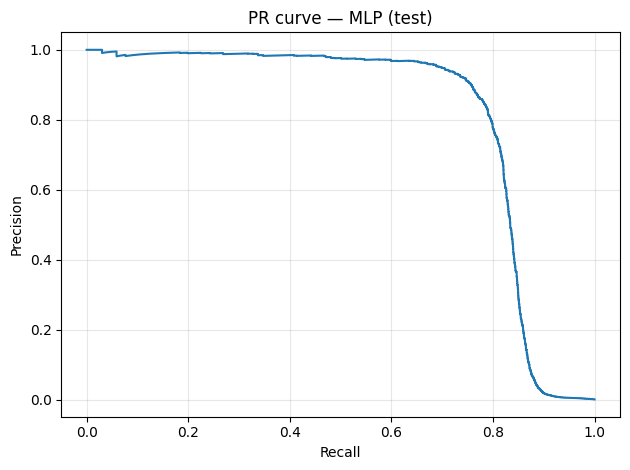

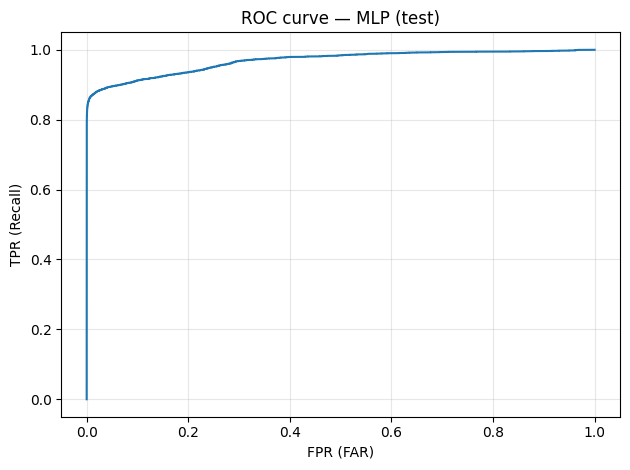

,thr,FAR,Recall
0,0.30,0.239707,0.947339
1,0.31,0.231114,0.943697
2,0.32,0.221739,0.941176
3,0.33,0.211792,0.938375
4,0.34,0.200874,0.935574
5,0.35,0.189289,0.933894
6,0.36,0.177420,0.931092
7,0.37,0.165233,0.928571
8,0.38,0.152244,0.925210
9,0.39,0.139297,0.921289


[INFO] Sem dados de pureza para MLP seed 43

--- Custo Computacional (Todos os Modelos) ---


train_seconds            rss_gb_start           rss_gb_end            \
                  mean        std         mean       std       mean       std   
model                                                                           
GATv2       241.710148   1.298168     7.254890  0.078525   7.347443  0.038882   
GINE        220.509976   1.415418     7.287526  0.029933   7.354911  0.018442   
LightGBM           NaN        NaN          NaN       NaN        NaN       NaN   
MLP          56.917714   3.327677     7.343698  0.031479   7.393711  0.010737   
PNA          99.807664  21.891626     7.316059  0.028285   7.375512  0.022163   
SAGE        216.685772   0.482213     7.101870  0.344316   7.314738  0.078976   
XGBoost            NaN        NaN          NaN       NaN        NaN       NaN   

         gpu_peak_gb       
                mean  std  
model                      
GATv2      17.540371  0.0  
GINE        7.916795  0.0  
LightGBM         NaN  NaN  
MLP         0.677535  0.0  
PNA        32.357498  0.0  
SAGE        2.416155  0.0  
XGBoost          NaN  NaN

[OK] Figuras focadas no GraphSAGE salvas em: /content/drive/MyDrive/DatasetDissertacao/IBM_TRANSACTION_AML/AMLSIMFULL/AML100k/plots


In [14]:
# %% [12] Relatórios: tabelas (comparação geral) + Foco no GraphSAGE (Plots)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, roc_curve

# Configuração: Qual modelo detalhar nos gráficos?
FORCE_MODEL_NAME = "GraphSAGE"  # Força o foco neste modelo

# Garante leitura correta
df = pd.read_csv(RESULTS_DIR / "results_v4_clean.csv")
print("Linhas no histórico:", len(df))
display(df.head(3))

# 1) Tabela LaTeX com TODOS os modelos (Média ± Desvio Padrão)
# Isso mantém a comparação que você queria mostrar
metric_cols = [c for c in df.columns if c.startswith("test_") and ("thr_" not in c)]
group = df.groupby("model")[metric_cols].agg(["mean","std"])
print("\n--- Tabela Comparativa Geral ---")
display(group)

latex_path = RESULTS_DIR / "table_results_v4_clean.tex"
with open(latex_path, "w", encoding="utf-8") as f:
    f.write(group.to_latex(float_format=lambda x: f"{x:.4f}"))
print("[OK] LaTeX da tabela geral salvo em:", latex_path)

# ---------------------------------------------------------
# 2) LÓGICA DE SELEÇÃO: Focar no GraphSAGE
# ---------------------------------------------------------
PROBS_DIR = RESULTS_DIR / "probs_v4"

# Filtra apenas o modelo forçado
df_target = df[df["model"] == FORCE_MODEL_NAME]

if df_target.empty:
    print(f"\n[AVISO] Modelo '{FORCE_MODEL_NAME}' não encontrado no CSV! Revertendo para o melhor global...")
    df_sorted = df.sort_values("val_AP", ascending=False)
else:
    print(f"\n[INFO] Focando análise detalhada no modelo: {FORCE_MODEL_NAME}")
    # Ordena as seeds do GraphSAGE pela melhor performance
    df_sorted = df_target.sort_values("val_AP", ascending=False)

best_model = None
best_seed = None
found_files = False

print("Procurando arquivos .npz correspondentes...")

for i, row in df_sorted.iterrows():
    m = row["model"]
    s = int(row["seed"])

    # Verifica se os arquivos existem antes de tentar carregar
    path_val = PROBS_DIR / f"{m}_seed{s}_val.npz"
    path_test = PROBS_DIR / f"{m}_seed{s}_test.npz"

    if path_val.exists() and path_test.exists():
        best_model = m
        best_seed = s
        found_files = True
        print(f"-> Selecionado para plots: {best_model} (seed {best_seed}) | val_AP={row['val_AP']:.4f}")
        break
    else:
        # print(f"   [Skip] {m} seed {s} (arquivos não encontrados)")
        pass

if not found_files:
    print("\n[ERRO] Nenhum arquivo .npz encontrado para o modelo selecionado!")
    print("Verifique se a pasta probs_v4 contém os arquivos do GraphSAGE.")
else:
    # ---------------------------------------------------------
    # Carrega e Plota (Gráficos focados no modelo escolhido)
    # ---------------------------------------------------------
    val_npz  = np.load(PROBS_DIR / f"{best_model}_seed{best_seed}_val.npz")
    test_npz = np.load(PROBS_DIR / f"{best_model}_seed{best_seed}_test.npz")
    y_val, p_val = val_npz["y"].astype(int), val_npz["p"].astype(float)
    y_te,  p_te  = test_npz["y"].astype(int), test_npz["p"].astype(float)

    # PR curve
    prec, rec, _ = precision_recall_curve(y_te, p_te)
    plt.figure()
    plt.plot(rec, prec)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"PR curve — {best_model} (test)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"fig_pr_{best_model}_test.png", dpi=200)
    plt.show()

    # ROC curve
    fpr, tpr, _ = roc_curve(y_te, p_te)
    plt.figure()
    plt.plot(fpr, tpr)
    plt.xlabel("FPR (FAR)")
    plt.ylabel("TPR (Recall)")
    plt.title(f"ROC curve — {best_model} (test)")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"fig_roc_{best_model}_test.png", dpi=200)
    plt.show()

    # Tabela Recall x FAR por grid de thresholds
    thr_grid = np.round(np.arange(0.30, 0.401, 0.01), 2)
    rows = []
    neg = (y_te == 0)
    pos = (y_te == 1)
    for thr in thr_grid:
        yhat = (p_te >= thr).astype(int)
        far = float(((yhat == 1) & neg).sum() / max(int(neg.sum()), 1))
        rec_thr = float(((yhat == 1) & pos).sum() / max(int(pos.sum()), 1))
        rows.append({"thr": float(thr), "FAR": far, "Recall": rec_thr})
    df_thr = pd.DataFrame(rows)
    display(df_thr)
    df_thr.to_csv(RESULTS_DIR / f"table_recall_far_thrgrid_{best_model}_test.csv", index=False)

    # Pureza vs k% (se existe)
    pur_path = RESULTS_DIR / "purity_v4_clean.csv"
    if pur_path.exists():
        pur = pd.read_csv(pur_path)
        # Filtra pelo modelo e seed selecionados
        pur_best = pur[(pur["model"]==best_model) & (pur["seed"]==best_seed)].sort_values("k%")

        if not pur_best.empty:
            display(pur_best)

            plt.figure()
            plt.plot(pur_best["k%"], pur_best["purity_macro_induced"], marker="o", label="macro (induced)")
            plt.plot(pur_best["k%"], pur_best["purity_weighted_induced"], marker="o", label="weighted (induced)")
            plt.plot(pur_best["k%"], pur_best["purity_macro_selected"], marker="x", label="macro (selected)")
            plt.plot(pur_best["k%"], pur_best["purity_weighted_selected"], marker="x", label="weighted (selected)")
            plt.xlabel("Orçamento k (%)")
            plt.ylabel("Pureza / contaminação")
            plt.title(f"Pureza de grupos — {best_model} (test)")
            plt.grid(True, alpha=0.3)
            plt.legend()
            plt.tight_layout()
            plt.savefig(PLOTS_DIR / f"fig_group_purity_{best_model}_test.png", dpi=200)
            plt.show()
        else:
            print(f"[INFO] Sem dados de pureza para {best_model} seed {best_seed}")
    else:
        print("[INFO] Arquivo de pureza não encontrado:", pur_path)

    # Custo (Exibe tabela de todos para comparar eficiência)
    cost_cols = ["train_seconds","rss_gb_start","rss_gb_end","gpu_peak_gb"]
    existing_cols = [c for c in cost_cols if c in df.columns]
    if existing_cols:
        cost = df.groupby("model")[existing_cols].agg(["mean","std"])
        print("\n--- Custo Computacional (Todos os Modelos) ---")
        display(cost)

    print("[OK] Figuras focadas no GraphSAGE salvas em:", PLOTS_DIR)

## (Opcional) Sweep de profundidade / épocas / seeds

Use esta seção apenas se você realmente precisar investigar profundidade. Em geral, **2–4 camadas** é uma faixa mais defensável para GNNs padrão.

Se você insistir em testar profundidades altas (ex.: 20–100), mantenha:

- **residual**
- **LayerNorm**
- **dropout**
- monitoramento por **AP/Recall@k** na validação (early stopping)


In [16]:
# %% [13] (Opcional) Sweep de profundidade (SAGE residual) — NÃO rodar por padrão
RUN_DEPTH_SWEEP = True  # mude para True para rodar

if RUN_DEPTH_SWEEP:
    depths = [2, 4, 8, 16, 32]  # evite 100 como primeiro teste
    hidden = 128

    sweep_rows = []
    for d in depths:
        def make_sage_depth():
            enc = SAGEEncoder(IN_NODE, hidden, layers=d, p=DROPOUT)
            return GNNEdgeModel(enc, hidden, IN_EDGE, p=DROPOUT)

        for seed in SEEDS:
            out, _ = train_gnn(
                model_name=f"SAGE_depth{d}",
                model_ctor=make_sage_depth,
                seed=seed,
                monitor=MONITOR,
                max_epochs=MAX_EPOCHS,
                patience=PATIENCE,
                eval_every=EVAL_EVERY,
                lr=LR,
                wd=WD,
                balance_train=BALANCE_TRAIN,
            )
            out["depth"] = d
            sweep_rows.append(out)

    df_sweep = pd.DataFrame(sweep_rows)
    display(df_sweep.sort_values("val_AP", ascending=False).head(10))
    df_sweep.to_csv(RESULTS_DIR / "sweep_depth_v4_clean.csv", index=False)
    print("[OK] Salvo:", RESULTS_DIR / "sweep_depth_v4_clean.csv")
else:
    print("[SKIP] RUN_DEPTH_SWEEP=False")


[SAGE_depth2 | seed=42] ep=005 loss=0.6282  val_AP=0.0179
[SAGE_depth2 | seed=42] ep=010 loss=0.5926  val_AP=0.0303
[SAGE_depth2 | seed=42] ep=015 loss=0.5679  val_AP=0.0483
[SAGE_depth2 | seed=42] ep=020 loss=0.5516  val_AP=0.0592
[SAGE_depth2 | seed=42] ep=025 loss=0.5379  val_AP=0.0689
[SAGE_depth2 | seed=42] ep=030 loss=0.5233  val_AP=0.0961
[SAGE_depth2 | seed=42] ep=035 loss=0.5089  val_AP=0.1105
[SAGE_depth2 | seed=42] ep=040 loss=0.4996  val_AP=0.1043
[SAGE_depth2 | seed=42] ep=045 loss=0.4807  val_AP=0.1141
[SAGE_depth2 | seed=42] ep=050 loss=0.4691  val_AP=0.1260
[SAGE_depth2 | seed=42] ep=055 loss=0.4544  val_AP=0.1513
[SAGE_depth2 | seed=42] ep=060 loss=0.4409  val_AP=0.2057
[SAGE_depth2 | seed=42] ep=065 loss=0.4275  val_AP=0.2368
[SAGE_depth2 | seed=42] ep=070 loss=0.4082  val_AP=0.2703
[SAGE_depth2 | seed=42] ep=075 loss=0.3969  val_AP=0.2992
[SAGE_depth2 | seed=42] ep=080 loss=0.3827  val_AP=0.3432
[SAGE_depth2 | seed=42] ep=085 loss=0.3681  val_AP=0.3976
[SAGE_depth2 |

,model,seed,setting,params,best_epoch,best_val_score,train_seconds,rss_gb_start,rss_gb_end,gpu_peak_gb,...,test_n_edges,test_thr_Prec,test_thr_Recall,test_thr_F1,test_thr_FAR,test_purity_macro_selected@1%,test_purity_weighted_selected@1%,test_purity_macro_induced@1%,test_purity_weighted_induced@1%,depth
2,SAGE_depth2,44,temporal,68481,200,0.833479,216.683209,5.631752,5.680061,4.351337,...,2490609,0.964750,0.789636,0.868453,0.000041,0.380220,0.142023,0.162917,0.089922,2
0,SAGE_depth2,42,temporal,68481,190,0.829561,217.590004,5.584255,5.646736,4.351337,...,2490609,0.930518,0.765266,0.839840,0.000082,0.380345,0.142316,0.161404,0.079586,2
1,SAGE_depth2,43,temporal,68481,195,0.820382,217.196712,5.583500,5.668961,4.351337,...,2490609,0.949199,0.779832,0.856220,0.000060,0.377106,0.145656,0.159471,0.086541,2
5,SAGE_depth4,44,temporal,134785,200,0.757973,228.476859,5.602024,5.676422,4.807311,...,2490609,0.921260,0.688235,0.787879,0.000084,0.391977,0.159957,0.166964,0.092293,4
4,SAGE_depth4,43,temporal,134785,190,0.748021,227.486675,5.608536,5.664345,4.807311,...,2490609,0.930435,0.659384,0.771803,0.000071,0.370392,0.166841,0.161849,0.092846,4
3,SAGE_depth4,42,temporal,134785,200,0.742582,225.315728,5.615017,5.670807,4.807311,...,2490609,0.946903,0.659384,0.777411,0.000053,0.370621,0.161441,0.160407,0.087785,4
8,SAGE_depth8,44,temporal,267393,190,0.495557,249.784777,5.602070,5.676453,5.623890,...,2490609,0.954445,0.363866,0.526871,0.000025,0.308919,0.168787,0.189811,0.119668,8
6,SAGE_depth8,42,temporal,267393,195,0.446799,250.259837,5.611324,5.676434,5.623890,...,2490609,0.875472,0.324930,0.473953,0.000066,0.303010,0.161706,0.199201,0.115401,8
7,SAGE_depth8,43,temporal,267393,200,0.388808,249.391235,5.611347,5.676453,5.623890,...,2490609,0.603829,0.344538,0.438737,0.000324,0.295201,0.155560,0.205955,0.122279,8
10,SAGE_depth16,43,temporal,532609,200,0.203538,295.888187,5.657818,5.676426,7.257050,...,2490609,0.328953,0.210364,0.256621,0.000616,0.232061,0.130593,0.174344,0.104914,16


[OK] Salvo: /content/drive/MyDrive/DatasetDissertacao/IBM_TRANSACTION_AML/AMLSIMFULL/AML100k/results/sweep_depth_v4_clean.csv


# (Novo) Experimento adicional: executar o pipeline final (GraphSAGE) no dataset AML1M

Esta seção **não altera** o que foi executado anteriormente (AML100k). Ela apenas adiciona um *segundo bloco* ao final do notebook que:

1. Carrega (ou reconstrói) o artefato `edge_data_v4_clean.pt` no diretório `AML1M`;
2. Roda **apenas** o modelo escolhido (GraphSAGE) no dataset `AML1M`;
3. Exporta estatísticas descritivas do dataset (AML1M), além de tabelas/figuras e um relatório de custo (tempo/memória) para enriquecer o Capítulo 5;
4. (Opcional) Exporta um exemplo de *caso* (componente conectada) do top-*k* para ilustração qualitativa.

**Observação:** se o `AML1M` for grande a ponto de estourar a GPU em *full-batch*, você pode:
- reduzir `AML1M_HIDDEN_DIM`;
- definir `AML1M_DEVICE = torch.device("cpu")` (mais lento, mas evita OOM na GPU);
- ou executar esta seção em uma GPU maior (A100 40/80GB, H100, etc.).


In [17]:
# %% [AML1M-0] Configuração do experimento AML1M (GraphSAGE only)

RUN_AML1M = True  # defina False para pular esta seção

# Caminho do dataset AML1M no Google Drive (conforme você indicou)
AML1M_PROJECT_DIR = BASE / "DatasetDissertacao/IBM_TRANSACTION_AML/AMLSIMFULL/AML1M"
AML1M_DATA_DIR    = AML1M_PROJECT_DIR
AML1M_ARTIF_DIR   = AML1M_PROJECT_DIR / "artifacts"

# Saídas separadas (não misturam com AML100k)
AML1M_TAG         = "aml1m_graphsage_only"
AML1M_RESULTS_DIR = AML1M_PROJECT_DIR / f"results_{AML1M_TAG}"
AML1M_PLOTS_DIR   = AML1M_PROJECT_DIR / f"plots_{AML1M_TAG}"
AML1M_OUTPUT_DIR  = AML1M_PROJECT_DIR / f"report_outputs_{AML1M_TAG}"

AML1M_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
AML1M_PLOTS_DIR.mkdir(parents=True, exist_ok=True)
(AML1M_OUTPUT_DIR / "tables").mkdir(parents=True, exist_ok=True)
(AML1M_OUTPUT_DIR / "figures").mkdir(parents=True, exist_ok=True)
AML1M_ARTIF_DIR.mkdir(parents=True, exist_ok=True)

AML1M_CACHE_PATH  = AML1M_ARTIF_DIR / "edge_data_v4_clean.pt"

# Seeds e hiperparâmetros (por padrão: 1 seed para reduzir custo)
AML1M_SEEDS       = [44]        # ajuste se quiser média±dp (ex.: [42, 43, 44])
AML1M_MAX_EPOCHS  = MAX_EPOCHS
AML1M_PATIENCE   = PATIENCE
AML1M_EVAL_EVERY = EVAL_EVERY
AML1M_LR         = LR
AML1M_WD         = WD
AML1M_BAL_TRAIN  = BALANCE_TRAIN

# Capacidade do modelo (pode reduzir caso dê OOM)
AML1M_HIDDEN_DIM  = HIDDEN_DIM
AML1M_LAYERS      = LAYERS
AML1M_DROPOUT     = DROPOUT

# Para datasets muito grandes, às vezes é necessário reduzir o chunk de inferência
AML1M_CHUNK_SIZE_EVAL = EVAL_CHUNK_SIZE
EVAL_CHUNK_SIZE = 100_000
# Se quiser forçar reconstrução do cache do AML1M:
AML1M_FORCE_REBUILD = False

# Se quiser depurar com subconjunto (NÃO usar para resultados finais):
AML1M_DEBUG_MAX_EDGES = None   # ex.: 2_000_000

# Device do AML1M (pode setar CPU para evitar OOM em full-batch)
AML1M_DEVICE = DEVICE  # ex.: torch.device("cpu")

print("[AML1M] PROJECT_DIR:", AML1M_PROJECT_DIR)
print("[AML1M] CACHE_PATH :", AML1M_CACHE_PATH)
print("[AML1M] RESULTS_DIR:", AML1M_RESULTS_DIR)
print("[AML1M] PLOTS_DIR  :", AML1M_PLOTS_DIR)
print("[AML1M] OUTPUT_DIR :", AML1M_OUTPUT_DIR)

# Backup do contexto atual (para opcionalmente restaurar no final)
_context_backup = {
    "PROJECT_DIR": PROJECT_DIR,
    "DATA_DIR": DATA_DIR,
    "ARTIF_DIR": ARTIF_DIR,
    "CACHE_PATH": CACHE_PATH,
    "RESULTS_DIR": RESULTS_DIR,
    "PLOTS_DIR": PLOTS_DIR,
    "OUTPUT_DIR": OUTPUT_DIR if "OUTPUT_DIR" in globals() else None,
    "FORCE_REBUILD": FORCE_REBUILD,
    "DEBUG_MAX_EDGES": DEBUG_MAX_EDGES,
    "DEVICE": DEVICE,
    # variáveis de dataset/cache (restauração completa é opcional)
    "x_train": x_train,
    "x_test": x_test,
    "mp_ei_train": mp_ei_train,
    "mp_ei_test": mp_ei_test,
    "mp_ea_train": mp_ea_train,
    "mp_ea_test": mp_ea_test,
    "ei_all_cpu": ei_all_cpu,
    "ea_all_cpu": ea_all_cpu,
    "y_all_cpu": y_all_cpu,
    "tr_idx": tr_idx,
    "va_idx": va_idx,
    "te_idx": te_idx,
}


[AML1M] PROJECT_DIR: /content/drive/MyDrive/DatasetDissertacao/IBM_TRANSACTION_AML/AMLSIMFULL/AML1M
[AML1M] CACHE_PATH : /content/drive/MyDrive/DatasetDissertacao/IBM_TRANSACTION_AML/AMLSIMFULL/AML1M/artifacts/edge_data_v4_clean.pt
[AML1M] RESULTS_DIR: /content/drive/MyDrive/DatasetDissertacao/IBM_TRANSACTION_AML/AMLSIMFULL/AML1M/results_aml1m_graphsage_only
[AML1M] PLOTS_DIR  : /content/drive/MyDrive/DatasetDissertacao/IBM_TRANSACTION_AML/AMLSIMFULL/AML1M/plots_aml1m_graphsage_only
[AML1M] OUTPUT_DIR : /content/drive/MyDrive/DatasetDissertacao/IBM_TRANSACTION_AML/AMLSIMFULL/AML1M/report_outputs_aml1m_graphsage_only


In [18]:
# %% [AML1M-1] Carregar/Construir cache do AML1M + estatísticas descritivas (sem misturar com AML100k)

if not RUN_AML1M:
    print("[AML1M] RUN_AML1M=False — pulando.")
else:
    import time, math, os, gc
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import torch
    from pathlib import Path

    # ----------------------------
    # Utilitários de custo
    # ----------------------------
    aml1m_cost_rows = []

    def _reset_gpu_peak():
        if torch.cuda.is_available():
            torch.cuda.reset_peak_memory_stats()

    def log_cost(stage, t0, extra=None):
        row = {
            "stage": stage,
            "seconds": float(time.perf_counter() - t0),
            "rss_gb": float(mem_rss_gb()),
            "gpu_peak_gb": float(gpu_peak_gb()),
        }
        if extra:
            row.update(extra)
        aml1m_cost_rows.append(row)
        print(f"[AML1M|COST] {stage}: {row['seconds']:.1f}s | rss={row['rss_gb']:.2f}GB | gpu_peak={row['gpu_peak_gb']:.2f}GB")

    def cleanup():
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    # ----------------------------
    # Troca de contexto (apenas a partir daqui)
    # ----------------------------
    PROJECT_DIR  = AML1M_PROJECT_DIR
    DATA_DIR     = AML1M_DATA_DIR
    ARTIF_DIR    = AML1M_ARTIF_DIR
    CACHE_PATH   = AML1M_CACHE_PATH
    RESULTS_DIR  = AML1M_RESULTS_DIR
    PLOTS_DIR    = AML1M_PLOTS_DIR
    OUTPUT_DIR   = AML1M_OUTPUT_DIR
    FORCE_REBUILD = AML1M_FORCE_REBUILD
    DEBUG_MAX_EDGES = AML1M_DEBUG_MAX_EDGES

    # IMPORTANTE: se mudar DEVICE, faça antes do build do cache
    DEVICE = AML1M_DEVICE

    print("[AML1M] DEVICE:", DEVICE)
    cleanup()

    # ----------------------------
    # 1) Carregar arquivo de transações
    # ----------------------------
    t0 = time.perf_counter()

    trx_path = find_first_recursive(
        DATA_DIR,
        candidates=[
            "transactions.csv", "transaction.csv", "tx.csv",
            "hi-large_trans.csv","hi-medium_trans.csv","hi-small_trans.csv",
            "li-large_trans.csv","li-medium_trans.csv","li-small_trans.csv",
            "transactions.parquet", "transaction.parquet", "tx.parquet",
            "edges.csv", "edge.csv"
        ],
    )
    if trx_path is None:
        raise FileNotFoundError(f"[AML1M] Não encontrei arquivo de transações em: {DATA_DIR}")

    trx_path = Path(trx_path)
    ext = trx_path.suffix.lower()

    if ext == ".parquet":
        # Parquet: carrega tudo (se estiver grande demais, converta para CSV ou ajuste leitura com pyarrow)
        transactions = pd.read_parquet(trx_path)
        transactions.columns = [c.strip().lower() for c in transactions.columns]
        # Inferência de colunas (usa pick_col)
        SRC_COL = pick_col(transactions, ["source", "src", "orig", "from", "sender", "account_from", "from_id", "payer"], "SRC")
        DST_COL = pick_col(transactions, ["target", "dst", "dest", "to", "receiver", "account_to", "to_id", "payee"], "DST")
        AMT_COL = pick_col(transactions, ["amount", "amt", "value", "transaction_amount", "tx_amount"], "AMOUNT")
        TIME_COL= pick_col(transactions, ["time", "timestamp", "ts", "step", "date", "datetime"], "TIME")
        TYPE_COL= pick_col(transactions, ["type", "transaction_type", "tx_type", "category"], "TYPE")
        Y_COL   = pick_col(transactions, ["label", "is_illicit", "illicit", "y", "fraud", "suspicious"], "LABEL")
    else:
        # CSV: lê amostra para inferir colunas sem carregar tudo primeiro
        sample = pd.read_csv(trx_path, nrows=2000)
        sample.columns = [c.strip() for c in sample.columns]
        norm_names = [c.strip().lower() for c in sample.columns]
        norm_to_orig = dict(zip(norm_names, sample.columns))

        sample_norm = sample.copy()
        sample_norm.columns = norm_names

       # CORREÇÃO AQUI: Adicionados "sender_account_id" e "receiver_account_id"
        SRC_COL = pick_col(sample_norm, ["sender_account_id", "source", "src", "orig", "from", "sender", "account_from", "from_id", "payer"], "SRC")
        DST_COL = pick_col(sample_norm, ["receiver_account_id", "target", "dst", "dest", "to", "receiver", "account_to", "to_id", "payee"], "DST")
        AMT_COL = pick_col(sample_norm, ["tx_amount", "amount", "amt", "value", "transaction_amount"], "AMOUNT")
        TIME_COL= pick_col(sample_norm, ["timestamp", "time", "ts", "step", "date", "datetime"], "TIME")
        TYPE_COL= pick_col(sample_norm, ["tx_type", "type", "transaction_type", "category"], "TYPE")
        Y_COL   = pick_col(sample_norm, ["is_fraud", "label", "is_illicit", "illicit", "y", "fraud", "suspicious"], "LABEL")

        usecols_orig = [norm_to_orig[c] for c in [SRC_COL, DST_COL, AMT_COL, TIME_COL, TYPE_COL, Y_COL]]
        transactions = pd.read_csv(trx_path, usecols=usecols_orig)
        transactions.columns = [c.strip().lower() for c in transactions.columns]

    log_cost("load_transactions_file", t0, {"path": str(trx_path), "rows": int(len(transactions))})

    # ----------------------------
    # 2) Construção do grafo (edge_index, edge_attr, y, ts)
    # ----------------------------
    t0 = time.perf_counter()

    df = transactions[[SRC_COL, DST_COL, AMT_COL, TIME_COL, TYPE_COL, Y_COL]].copy()

    df[SRC_COL] = df[SRC_COL].astype(str)
    df[DST_COL] = df[DST_COL].astype(str)
    df[Y_COL]   = df[Y_COL].astype(int)

    # timestamp -> int64
    if not np.issubdtype(df[TIME_COL].dtype, np.number):
        df[TIME_COL] = pd.to_datetime(df[TIME_COL], errors="coerce")
        if df[TIME_COL].isna().any():
            raise ValueError("[AML1M] Falha ao converter TIME_COL para datetime. Verifique o formato.")
        df[TIME_COL] = df[TIME_COL].astype("int64")  # ns
    ts = df[TIME_COL].to_numpy().astype(np.int64)

    # amount -> log1p
    amt = df[AMT_COL].to_numpy().astype(np.float64)
    log_amt = np.log1p(np.maximum(amt, 0.0)).astype(np.float32)

    # type one-hot
    tx_type = df[TYPE_COL].astype(str)
    type_ohe = pd.get_dummies(tx_type, prefix="type", dtype=np.int8)
    ea_df_raw = pd.concat([pd.Series(log_amt, name="_log_amt"), type_ohe], axis=1)

    # Mapear contas -> ids (factorize é eficiente)
    E0 = len(df)
    codes, uniques = pd.factorize(pd.concat([df[SRC_COL], df[DST_COL]], axis=0), sort=False)
    src_id = codes[:E0].astype(np.int64)
    dst_id = codes[E0:].astype(np.int64)
    N = int(len(uniques))

    edge_index_np = np.stack([src_id, dst_id], axis=0).astype(np.int64)
    y_all = df[Y_COL].to_numpy().astype(np.int64)

    # remove self-loops
    not_self = edge_index_np[0] != edge_index_np[1]
    if not np.all(not_self):
        edge_index_np = edge_index_np[:, not_self]
        ea_df_raw = ea_df_raw.loc[not_self].reset_index(drop=True)
        y_all = y_all[not_self]
        ts = ts[not_self]

    # debug opcional
    E = int(edge_index_np.shape[1])
    if DEBUG_MAX_EDGES is not None and E > int(DEBUG_MAX_EDGES):
        keep = np.random.RandomState(0).choice(np.arange(E), size=int(DEBUG_MAX_EDGES), replace=False)
        keep.sort()
        edge_index_np = edge_index_np[:, keep]
        ea_df_raw = ea_df_raw.iloc[keep].reset_index(drop=True)
        y_all = y_all[keep]
        ts = ts[keep]
        E = int(edge_index_np.shape[1])
        print(f"[AML1M] DEBUG_MAX_EDGES aplicado: E={E}")

    log_cost("build_graph_arrays", t0, {"N": int(N), "E": int(E), "n_pos": int(y_all.sum()), "edge_feat_dim": int(ea_df_raw.shape[1])})

    # ----------------------------
    # 3) Split temporal (mesma lógica do notebook)
    # ----------------------------
    t0 = time.perf_counter()

    # --- CORREÇÃO APLICADA AQUI (usando *_) ---
    # O *_ captura quaisquer valores extras retornados além dos 3 primeiros
    tr_mask, va_mask, te_mask, *_ = temporal_split(ts, y_all, train_frac=TRAIN_FRAC, val_frac=VAL_FRAC)

    tr_idx = np.where(tr_mask)[0]
    va_idx = np.where(va_mask)[0]
    te_idx = np.where(te_mask)[0]

    y_tr = y_all[tr_idx]
    y_va = y_all[va_idx]
    y_te = y_all[te_idx]

    log_cost("temporal_split", t0, {
        "E_tr": int(len(tr_idx)), "E_va": int(len(va_idx)), "E_te": int(len(te_idx)),
        "pos_tr": int(y_tr.sum()), "pos_va": int(y_va.sum()), "pos_te": int(y_te.sum()),
        "prev_te": float(y_te.mean()) if len(y_te) else np.nan,
    })

    # ----------------------------
    # 4) Cache (scaler train-only + node feats sem leakage + mp graphs)
    # ----------------------------
    t0 = time.perf_counter()
    _reset_gpu_peak()

    if CACHE_PATH.exists() and (not FORCE_REBUILD):
        print("[AML1M|CACHE] Carregando:", CACHE_PATH)
        cache = torch_load_cache(CACHE_PATH, map_location="cpu")
        if cache.get("SETTING") != SETTING or cache.get("TRAIN_FRAC") != TRAIN_FRAC or cache.get("VAL_FRAC") != VAL_FRAC:
            print("[AML1M|CACHE] Config mudou (SETTING/split). Reconstruindo...")
            cache = build_all_and_cache()
            torch.save(cache, CACHE_PATH)
    else:
        print("[AML1M|CACHE] Construindo do zero...")
        cache = build_all_and_cache()
        torch.save(cache, CACHE_PATH)

    log_cost("build_or_load_cache", t0, {"cache_path": str(CACHE_PATH), "cache_size_gb": float(CACHE_PATH.stat().st_size/(1024**3))})

    # Extrai tensores para o pipeline AML1M
    x_train = cache["x_train"].to(DEVICE)
    x_test  = cache["x_test"].to(DEVICE)

    mp_ei_train = cache["mp_ei_train"].to(DEVICE)
    mp_ei_test  = cache["mp_ei_test"].to(DEVICE)

    mp_ea_train = cache["mp_ea_train"].to(DEVICE)
    mp_ea_test  = cache["mp_ea_test"].to(DEVICE)

    ei_all_cpu = cache["ei_all_cpu"]  # CPU
    ea_all_cpu = cache["ea_all_cpu"]  # CPU
    y_all_cpu  = cache["y_all_cpu"]   # CPU

    # ----------------------------
    # 5) Estatísticas descritivas básicas (AML1M)
    # ----------------------------
    t0 = time.perf_counter()

    stats = {
        "dataset": "AML1M",
        "SETTING": SETTING,
        "N_nodes": int(N),
        "E_edges": int(E),
        "train_frac": float(TRAIN_FRAC),
        "val_frac": float(VAL_FRAC),
        "E_tr": int(len(tr_idx)),
        "E_va": int(len(va_idx)),
        "E_te": int(len(te_idx)),
        "pos_tr": int(y_tr.sum()),
        "pos_va": int(y_va.sum()),
        "pos_te": int(y_te.sum()),
        "prev_tr": float(y_tr.mean()) if len(y_tr) else np.nan,
        "prev_va": float(y_va.mean()) if len(y_va) else np.nan,
        "prev_te": float(y_te.mean()) if len(y_te) else np.nan,
        "edge_feat_dim": int(ea_df_raw.shape[1]),
        "node_feat_dim": int(x_train.shape[1]),
        "ts_min": int(ts.min()) if len(ts) else None,
        "ts_max": int(ts.max()) if len(ts) else None,
        "n_types": int(type_ohe.shape[1]),
    }

    df_stats = pd.DataFrame([stats])
    display(df_stats)

    (OUTPUT_DIR/"tables"/"AML1M_dataset_stats.csv").write_text(df_stats.to_csv(index=False), encoding="utf-8")
    (OUTPUT_DIR/"tables"/"AML1M_dataset_stats.tex").write_text(df_stats.to_latex(index=False, escape=False), encoding="utf-8")

    # Sumário de amount (em log)
    amt_s = pd.Series(log_amt)
    amt_desc = amt_s.describe(percentiles=[0.5,0.9,0.99]).to_frame("log_amt")
    display(amt_desc)
    amt_desc.to_csv(OUTPUT_DIR/"tables"/"AML1M_amount_log_desc.csv")
    (OUTPUT_DIR/"tables"/"AML1M_amount_log_desc.tex").write_text(amt_desc.to_latex(escape=False), encoding="utf-8")

    log_cost("descriptive_stats", t0)

    # Salva custo parcial (até aqui)
    df_cost = pd.DataFrame(aml1m_cost_rows)
    df_cost.to_csv(OUTPUT_DIR/"tables"/"AML1M_cost_log_partial.csv", index=False)
    display(df_cost)

[AML1M] DEVICE: cuda
[AML1M|COST] load_transactions_file: 81.8s | rss=9.72GB | gpu_peak=10.52GB
[AML1M|COST] build_graph_arrays: 165.9s | rss=39.01GB | gpu_peak=10.52GB
[AML1M|COST] temporal_split: 5.5s | rss=41.22GB | gpu_peak=10.52GB
[AML1M|CACHE] Carregando: /content/drive/MyDrive/DatasetDissertacao/IBM_TRANSACTION_AML/AMLSIMFULL/AML1M/artifacts/edge_data_v4_clean.pt
[AML1M|COST] build_or_load_cache: 15.6s | rss=50.81GB | gpu_peak=0.48GB


,dataset,SETTING,N_nodes,E_edges,train_frac,val_frac,E_tr,E_va,E_te,pos_tr,pos_va,pos_te,prev_tr,prev_va,prev_te,edge_feat_dim,node_feat_dim,ts_min,ts_max,n_types
0,AML1M,temporal,1000000,124702996,0.6,0.2,75443753,24934639,24324604,98056,32477,32404,0.0013,0.001302,0.001332,2,6,0,199,1


,log_amt
count,1.247032e+08
mean,4.773922e+00
std,2.648098e+00
min,0.000000e+00
50%,5.045745e+00
90%,6.315973e+00
99%,1.285306e+01
max,1.688239e+01


[AML1M|COST] descriptive_stats: 3.4s | rss=50.81GB | gpu_peak=5.11GB


,stage,seconds,rss_gb,gpu_peak_gb,path,rows,N,E,n_pos,edge_feat_dim,E_tr,E_va,E_te,pos_tr,pos_va,pos_te,prev_te,cache_path,cache_size_gb
0,load_transactions_file,81.797446,9.717720,10.523369,/content/drive/MyDrive/DatasetDissertacao/IBM_...,124703184.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,build_graph_arrays,165.883502,39.010933,10.523369,NaN,NaN,1000000.0,124702996.0,162937.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,temporal_split,5.487634,41.217590,10.523369,NaN,NaN,NaN,NaN,NaN,NaN,75443753.0,24934639.0,24324604.0,98056.0,32477.0,32404.0,0.001332,NaN,NaN
3,build_or_load_cache,15.606719,50.805374,0.477288,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,/content/drive/MyDrive/DatasetDissertacao/IBM_...,10.258968
4,descriptive_stats,3.388784,50.805428,5.108652,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [19]:
# %% [AML1M-2] Treinar e avaliar apenas GraphSAGE no AML1M (salvando métricas, probs e custo)


if not RUN_AML1M:
    print("[AML1M] RUN_AML1M=False — pulando.")
else:
    # --- CORREÇÃO DE MEMÓRIA (Deve vir antes de outros imports torch se possível) ---
    import os
    os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

    import time
    import pandas as pd
    import torch
    import gc

    # Garante diretórios padrão do pipeline
    PROBS_DIR = RESULTS_DIR / "probs_v4"
    PROBS_DIR.mkdir(parents=True, exist_ok=True)

    # Wrapper para medir tempo das inferências
    _predict_proba_edges_orig = predict_proba_edges
    _timing_rows = []

    def predict_proba_edges_timed(*args, **kwargs):
        t0 = time.perf_counter()
        out = _predict_proba_edges_orig(*args, **kwargs)
        dt = time.perf_counter() - t0
        try:
            idx_edges = args[4]
            n_edges = int(len(idx_edges))
        except Exception:
            n_edges = None
        _timing_rows.append({"stage": "predict_proba_edges", "seconds": float(dt), "n_edges": n_edges})
        return out

    predict_proba_edges = predict_proba_edges_timed

    # Constrói o modelo
    def make_sage_aml1m():
        enc = SAGEEncoder(x_train.shape[1], AML1M_HIDDEN_DIM, layers=AML1M_LAYERS, p=AML1M_DROPOUT)
        return GNNEdgeModel(enc, AML1M_HIDDEN_DIM, ea_all_cpu.shape[1], p=AML1M_DROPOUT)

    results = []
    purity_logs = []

    for seed in AML1M_SEEDS:
        # --- LIMPEZA DE MEMÓRIA ANTES DE CADA RODADA ---
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.ipc_collect()

        # Tenta usar a função de limpeza do notebook, se existir
        try:
            cleanup_cuda()
        except NameError:
            pass

        print(f"[AML1M] Iniciando seed {seed} | Memória Livre: {torch.cuda.mem_get_info()[0]/1e9:.2f} GB")
        t0 = time.perf_counter()

        try:
            out, purity_df = train_gnn(
                model_name="GraphSAGE",
                model_ctor=make_sage_aml1m,
                seed=int(seed),
                max_epochs=AML1M_MAX_EPOCHS,
                patience=AML1M_PATIENCE,
                eval_every=AML1M_EVAL_EVERY,
                chunk_size_eval=AML1M_CHUNK_SIZE_EVAL,
                lr=AML1M_LR,
                wd=AML1M_WD,
                balance_train=AML1M_BAL_TRAIN,
                monitor=MONITOR,
            )

            out["dataset"] = "AML1M"
            out["wall_total_seconds"] = float(time.perf_counter() - t0)

            results.append(out)
            purity_df["model"] = "GraphSAGE"
            purity_df["seed"] = int(seed)
            purity_df["dataset"] = "AML1M"
            purity_logs.append(purity_df)

            print("[AML1M] Concluído seed", seed)

        except torch.cuda.OutOfMemoryError as e:
            print(f"[AML1M] ERRO DE MEMÓRIA NA SEED {seed}. Tentando limpar e continuar...")
            print(e)
            gc.collect()
            torch.cuda.empty_cache()
            # Opcional: break ou continue. Aqui seguimos para tentar salvar o que deu ou próxima seed
            continue

    # Restaura função original
    predict_proba_edges = _predict_proba_edges_orig

    if results:
        df_res = pd.DataFrame(results)
        df_res.to_csv(RESULTS_DIR / "results_v4_clean.csv", index=False)
        display(df_res)
    else:
        print("[AML1M] Nenhum resultado gerado (OOM em todas as seeds?)")

    if purity_logs:
        df_pur = pd.concat(purity_logs, ignore_index=True)
        df_pur.to_csv(RESULTS_DIR / "purity_v4_clean.csv", index=False)
        display(df_pur.head())

    # Logs de timing de inferência
    df_timing = pd.DataFrame(_timing_rows)
    if not df_timing.empty:
        display(df_timing)
        df_timing.to_csv(OUTPUT_DIR/"tables"/"AML1M_inference_timing_calls.csv", index=False)

    # Atualiza custo consolidado
    df_cost = pd.DataFrame(aml1m_cost_rows)
    df_cost.to_csv(OUTPUT_DIR/"tables"/"AML1M_cost_log_until_training.csv", index=False)

    print("[AML1M] Processo finalizado.")

[AML1M] Iniciando seed 44 | Memória Livre: 79.00 GB
[GraphSAGE | seed=44] ep=005 loss=0.6521  val_AP=0.0220
[GraphSAGE | seed=44] ep=010 loss=0.6104  val_AP=0.1133
[GraphSAGE | seed=44] ep=015 loss=0.5824  val_AP=0.1410
[GraphSAGE | seed=44] ep=020 loss=0.5644  val_AP=0.1518
[GraphSAGE | seed=44] ep=025 loss=0.5493  val_AP=0.1632
[GraphSAGE | seed=44] ep=030 loss=0.5358  val_AP=0.1787
[GraphSAGE | seed=44] ep=035 loss=0.5234  val_AP=0.1943
[GraphSAGE | seed=44] ep=040 loss=0.5117  val_AP=0.2066
[GraphSAGE | seed=44] ep=045 loss=0.4983  val_AP=0.2180
[GraphSAGE | seed=44] ep=050 loss=0.4874  val_AP=0.2301
[GraphSAGE | seed=44] ep=055 loss=0.4753  val_AP=0.2456
[GraphSAGE | seed=44] ep=060 loss=0.4633  val_AP=0.2645
[GraphSAGE | seed=44] ep=065 loss=0.4504  val_AP=0.2831
[GraphSAGE | seed=44] ep=070 loss=0.4376  val_AP=0.3002
[GraphSAGE | seed=44] ep=075 loss=0.4253  val_AP=0.3204
[GraphSAGE | seed=44] ep=080 loss=0.4126  val_AP=0.3450
[GraphSAGE | seed=44] ep=085 loss=0.4013  val_AP=0.3

,model,seed,setting,params,best_epoch,best_val_score,train_seconds,rss_gb_start,rss_gb_end,gpu_peak_gb,...,test_thr_Prec,test_thr_Recall,test_thr_F1,test_thr_FAR,test_purity_macro_selected@1%,test_purity_weighted_selected@1%,test_purity_macro_induced@1%,test_purity_weighted_induced@1%,dataset,wall_total_seconds
0,GraphSAGE,44,temporal,17857,200,0.822754,2340.530745,51.928913,52.263294,24.628494,...,0.931042,0.774997,0.845883,0.000077,0.43587,0.11824,0.185727,0.067622,AML1M,2501.418115


,k%,n_groups,purity_macro_selected,purity_weighted_selected,purity_macro_induced,purity_weighted_induced,edges_in_groups_induced,pos_in_groups_induced,model,seed,dataset
0,1.0,10546,0.435870,0.118240,0.185727,0.067622,398763,26965,GraphSAGE,44,AML1M
1,2.0,10494,0.289520,0.059248,0.126177,0.027603,1014675,28008,GraphSAGE,44,AML1M
2,5.0,4549,0.208806,0.023734,0.096518,0.006538,4641021,30343,GraphSAGE,44,AML1M
3,10.0,1388,0.188040,0.012206,0.093394,0.003601,8750003,31506,GraphSAGE,44,AML1M


,stage,seconds,n_edges
0,predict_proba_edges,34.268966,24934639
1,predict_proba_edges,34.478920,24934639
2,predict_proba_edges,34.298514,24934639
3,predict_proba_edges,34.601835,24934639
4,predict_proba_edges,33.911653,24934639
5,predict_proba_edges,34.756221,24934639
6,predict_proba_edges,34.053200,24934639
7,predict_proba_edges,33.914341,24934639
8,predict_proba_edges,33.974180,24934639
9,predict_proba_edges,34.746740,24934639


[AML1M] Processo finalizado.


,k%,|E_k|,#casos,Recall@k (total),Recall_em_casos@k,Cobertura(casos),CR@k (intra-caso),Pureza_induzida(weighted),|E_ind|,|Y+_ind|,E_ind/E_k,Frac_topk_edges_em_casos,Frac_topk_pos_em_casos,seconds_group_stats,min_nodes,dataset,model,seed
0,1%,243247,10546,0.869615,0.800858,0.832150,0.962396,0.067622,398763,26965,1.639334,0.902285,0.920934,4.758124,3,AML1M,GraphSAGE,44
1,2%,486493,10494,0.880663,0.827398,0.864338,0.957262,0.027603,1014675,28008,2.085693,0.930165,0.939517,5.500557,3,AML1M,GraphSAGE,44
2,5%,1216231,4549,0.899241,0.871806,0.936397,0.931022,0.006538,4641021,30343,3.815904,0.978664,0.969491,7.725978,3,AML1M,GraphSAGE,44
3,10%,2432461,1388,0.923621,0.911153,0.972287,0.937123,0.003601,8750003,31506,3.597181,0.994441,0.986501,11.236760,3,AML1M,GraphSAGE,44


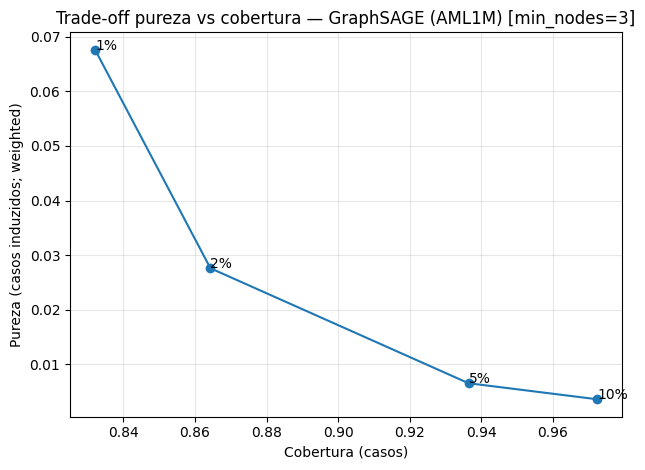

[AML1M] Export OK: /content/drive/MyDrive/DatasetDissertacao/IBM_TRANSACTION_AML/AMLSIMFULL/AML1M/report_outputs_aml1m_graphsage_only/tables/AML1M_Tabela_Fase2_grupos_GraphSAGE_seed44_min3.csv


In [20]:
# %% [AML1M-3 FIX v2] Fase 2 (casos) — CR coerente com min_nodes + reexport
# Objetivo: evitar CR@k > 1 quando usamos filtro estrutural (min_nodes>=3).
# Define CR@k como completude intra-caso: Recall_em_casos@k / Cobertura(casos)

if not RUN_AML1M:
    print("[AML1M] RUN_AML1M=False — pulando.")
else:
    import time, math
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from pathlib import Path

    # =========================
    # Config
    # =========================
    CASE_MIN_NODES = 3              # mantém seu filtro operacional
    KS_PCT = [1, 2, 5, 10]          # orçamentos
    best_model = "GraphSAGE"        # ajuste se você tiver outra lógica de "best"
    best_seed  = 44                 # ajuste conforme seu best

    # --- CORREÇÃO: Define TABLE_DIR ---
    TABLE_DIR = OUTPUT_DIR / "tables"
    (TABLE_DIR).mkdir(parents=True, exist_ok=True)
    (PLOTS_DIR).mkdir(parents=True, exist_ok=True)

    # --- CORREÇÃO: Recupera o grafo completo (edge_index_np_all) ---
    # Assume que 'ei_all_cpu' existe (criado na Célula 1)
    if 'ei_all_cpu' in globals():
        edge_index_np_all = ei_all_cpu.numpy() if hasattr(ei_all_cpu, "numpy") else np.array(ei_all_cpu)
    else:
        raise NameError("A variável 'ei_all_cpu' não foi encontrada. Por favor, execute a Célula [AML1M-1] primeiro.")

    # =========================
    # Carregar probs do teste (garante consistência)
    # =========================
    npz_path = PROBS_DIR / f"{best_model}_seed{best_seed}_test.npz"
    if not npz_path.exists():
        raise FileNotFoundError(f"[AML1M] Não encontrei probs do teste em: {npz_path}")

    npz = np.load(npz_path)
    p_te = np.asarray(npz["p"], dtype=float)
    y_te = np.asarray(npz["y"], dtype=int)

    # Garantir te_idx_np
    te_idx_np = te_idx.numpy() if hasattr(te_idx, "numpy") else np.asarray(te_idx, dtype=np.int64)

    assert len(p_te) == len(y_te) == len(te_idx_np), "Inconsistência: p_te, y_te e te_idx_np com tamanhos diferentes."

    pos_te = int(y_te.sum())
    E_te = int(len(y_te))
    pi = float(pos_te / max(E_te, 1))

    # =========================
    # Helper: top-k metrics (transação)
    # =========================
    def topk_counts(y, scores, k_pct):
        E = len(y)
        K = max(1, int(math.ceil((k_pct/100.0) * E)))
        # argpartition é mais barato que sort completo
        idx = np.argpartition(-scores, K-1)[:K]
        yk = y[idx]
        pos_k = int(yk.sum())
        return K, pos_k

    # Mapa de Recall@k total (transação)
    rec_map = {}
    prec_map = {}
    lift_map = {}
    posk_map = {}
    K_map = {}

    for k in KS_PCT:
        K, pos_k = topk_counts(y_te, p_te, k)
        rec = float(pos_k / max(pos_te, 1))
        prec = float(pos_k / max(K, 1))
        lift = float(prec / max(pi, 1e-12))
        rec_map[f"{k}%"] = rec
        prec_map[f"{k}%"] = prec
        lift_map[f"{k}%"] = lift
        posk_map[f"{k}%"] = pos_k
        K_map[f"{k}%"] = K

    # =========================
    # Helper: grupos com contagem de positivos selecionados (casos) + induzidos
    # =========================
    def group_stats_with_selected_counts(y_edge, edge_index_2xE, scores, k_pct=1.0, min_nodes=3):
        """
        - Seleciona top-k% arestas por score.
        - Extrai componentes (grafo não-direcionado) a partir dessas arestas selecionadas.
        - Aplica filtro min_nodes.
        - Retorna:
            * contagens e purezas usando SOMENTE arestas selecionadas (dentro de casos válidos)
            * contagens e purezas INDUZIDAS considerando TODAS as arestas internas ao caso (no edge_index_2xE fornecido)
        Observação: edge_index_2xE e y_edge devem estar no MESMO universo (aqui: teste).
        """
        y_edge = np.asarray(y_edge).astype(int)
        scores = np.asarray(scores).astype(float)
        u = edge_index_2xE[0].astype(np.int64)
        v = edge_index_2xE[1].astype(np.int64)
        E = len(y_edge)

        k = max(1, int(np.ceil((k_pct/100.0) * E)))
        order = np.argsort(-scores)
        sel = order[:k]
        u_sel = u[sel]
        v_sel = v[sel]

        # Nós envolvidos no top-k (selecionado)
        nodes = np.unique(np.concatenate([u_sel, v_sel]))
        # Mapear node_id -> [0..n-1] para union-find compacto
        node_map = {int(n): i for i, n in enumerate(nodes)}
        us = np.fromiter((node_map[int(x)] for x in u_sel), dtype=np.int64)
        vs = np.fromiter((node_map[int(x)] for x in v_sel), dtype=np.int64)

        # Union-Find
        parent = np.arange(len(nodes), dtype=np.int64)
        rank = np.zeros(len(nodes), dtype=np.int64)

        def find(a):
            while parent[a] != a:
                parent[a] = parent[parent[a]]
                a = parent[a]
            return a

        def union(a, b):
            ra, rb = find(a), find(b)
            if ra == rb:
                return
            if rank[ra] < rank[rb]:
                parent[ra] = rb
            elif rank[ra] > rank[rb]:
                parent[rb] = ra
            else:
                parent[rb] = ra
                rank[ra] += 1

        # Grafo não-direcionado: basta unir (us,vs); não precisa duplicar arestas
        for a, b in zip(us, vs):
            union(int(a), int(b))

        comp = np.array([find(i) for i in range(len(nodes))], dtype=np.int64)
        _, comp_ids = np.unique(comp, return_inverse=True)

        # tamanho em nós por componente
        nodes_per = np.bincount(comp_ids)
        valid_comp = nodes_per >= int(min_nodes)

        # se nenhum caso válido, retorna zeros
        if not np.any(valid_comp):
            return {
                "k%": float(k_pct),
                "n_groups": 0,
                "k_edges_total": int(k),
                "edges_in_groups_selected": 0,
                "pos_in_groups_selected": 0,
                "edges_in_groups_induced": 0,
                "pos_in_groups_induced": 0,
                "purity_weighted_selected": np.nan,
                "purity_weighted_induced": np.nan,
            }

        # remap comp_ids -> gid apenas para comps válidos
        gid_map = -np.ones(int(comp_ids.max()+1), dtype=np.int64)
        gids = np.flatnonzero(valid_comp)
        gid_map[gids] = np.arange(len(gids), dtype=np.int64)

        # gid_of_node (no espaço de node_id original)
        gid_of_node = -np.ones(int(max(u.max(), v.max()) + 1), dtype=np.int64)
        # cuidado: node_id pode ser grande, mas aqui em AMLSim costuma ser 0..N-1
        # se não for, essa linha pode estourar; nesse caso usar dict em vez de array.
        for node_id, local_idx in node_map.items():
            gid = gid_map[comp_ids[local_idx]]
            if gid >= 0:
                gid_of_node[node_id] = gid

        n_groups = int(len(gids))

        # ===== Selecionadas (dentro de casos válidos)
        y_sel = y_edge[sel].astype(np.int64)
        g_sel = gid_of_node[u_sel]  # componente do u_sel (= v_sel)
        valid_sel = (g_sel >= 0)
        g_sel_v = g_sel[valid_sel]
        y_sel_v = y_sel[valid_sel]

        edges_in_groups_selected = int(g_sel_v.size)
        pos_in_groups_selected = int(y_sel_v.sum())
        purity_weighted_selected = float(pos_in_groups_selected / max(edges_in_groups_selected, 1))

        # ===== Induzidas: todas arestas do universo fornecido (teste) dentro dos casos válidos
        gu = gid_of_node[u]
        gv = gid_of_node[v]
        mask_in = (gu >= 0) & (gu == gv)

        y_in = y_edge[mask_in].astype(np.int64)
        edges_in_groups_induced = int(mask_in.sum())
        pos_in_groups_induced = int(y_in.sum())
        purity_weighted_induced = float(pos_in_groups_induced / max(edges_in_groups_induced, 1))

        return {
            "k%": float(k_pct),
            "n_groups": int(n_groups),
            "k_edges_total": int(k),
            "edges_in_groups_selected": edges_in_groups_selected,
            "pos_in_groups_selected": pos_in_groups_selected,
            "edges_in_groups_induced": edges_in_groups_induced,
            "pos_in_groups_induced": pos_in_groups_induced,
            "purity_weighted_selected": purity_weighted_selected,
            "purity_weighted_induced": purity_weighted_induced,
        }

    # =========================
    # Computar tabela Fase 2 coerente com min_nodes
    # =========================
    phase2_rows = []
    for k_pct in KS_PCT:
        t0 = time.perf_counter()
        gp = group_stats_with_selected_counts(
            y_te,
            edge_index_np_all[:, te_idx_np],   # universo do teste
            p_te,
            k_pct=float(k_pct),
            min_nodes=int(CASE_MIN_NODES)
        )
        dt = time.perf_counter() - t0

        K = int(K_map[f"{k_pct}%"])
        pos_k = int(posk_map[f"{k_pct}%"])
        rec_total = float(rec_map[f"{k_pct}%"])  # Recall@k transacional (sem filtro)

        # Métricas coerentes com casos (após filtro)
        cov_cases = float(gp["pos_in_groups_induced"] / max(pos_te, 1))
        rec_in_cases = float(gp["pos_in_groups_selected"] / max(pos_te, 1))
        cr_cases = float(rec_in_cases / max(cov_cases, 1e-12)) if np.isfinite(cov_cases) else np.nan  # <= 1

        # Quanto do top-k ficou fora dos casos (por causa do min_nodes)
        frac_edges_in_cases = float(gp["edges_in_groups_selected"] / max(K, 1))
        frac_pos_in_cases = float(gp["pos_in_groups_selected"] / max(pos_k, 1))

        phase2_rows.append({
            "k%": f"{k_pct}%",
            "|E_k|": K,
            "#casos": int(gp["n_groups"]),
            "Recall@k (total)": rec_total,
            "Recall_em_casos@k": rec_in_cases,
            "Cobertura(casos)": cov_cases,
            "CR@k (intra-caso)": cr_cases,
            "Pureza_induzida(weighted)": float(gp["purity_weighted_induced"]),
            "|E_ind|": int(gp["edges_in_groups_induced"]),
            "|Y+_ind|": int(gp["pos_in_groups_induced"]),
            "E_ind/E_k": float(gp["edges_in_groups_induced"] / max(K, 1)),
            "Frac_topk_edges_em_casos": frac_edges_in_cases,
            "Frac_topk_pos_em_casos": frac_pos_in_cases,
            "seconds_group_stats": float(dt),
            "min_nodes": int(CASE_MIN_NODES),
            "dataset": "AML1M",
            "model": best_model,
            "seed": best_seed
        })

    df_phase2 = pd.DataFrame(phase2_rows)
    display(df_phase2)

    # Export
    df_phase2.to_csv(TABLE_DIR / f"AML1M_Tabela_Fase2_grupos_{best_model}_seed{best_seed}_min{CASE_MIN_NODES}.csv", index=False)
    (TABLE_DIR / f"AML1M_Tabela_Fase2_grupos_{best_model}_seed{best_seed}_min{CASE_MIN_NODES}.tex").write_text(
        df_phase2.to_latex(index=False, escape=False),
        encoding="utf-8"
    )

    # Figura trade-off (cobertura vs pureza induzida)
    plt.figure(figsize=(6.5,4.8))
    plt.plot(df_phase2["Cobertura(casos)"].astype(float),
             df_phase2["Pureza_induzida(weighted)"].astype(float),
             marker="o")
    for _, r in df_phase2.iterrows():
        plt.annotate(str(r["k%"]),
                     (float(r["Cobertura(casos)"]), float(r["Pureza_induzida(weighted)"])))
    plt.xlabel("Cobertura (casos)")
    plt.ylabel("Pureza (casos induzidos; weighted)")
    plt.title(f"Trade-off pureza vs cobertura — {best_model} (AML1M) [min_nodes={CASE_MIN_NODES}]")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"AML1M_fig_tradeoff_pureza_cobertura_{best_model}_seed{best_seed}_min{CASE_MIN_NODES}.png", dpi=200)
    plt.show()

    print("[AML1M] Export OK:",
          (TABLE_DIR / f"AML1M_Tabela_Fase2_grupos_{best_model}_seed{best_seed}_min{CASE_MIN_NODES}.csv"))

In [ ]:
# %% [AML1M-4] (Opcional) Restaurar contexto AML100k (útil se você quiser continuar usando variáveis do primeiro experimento)

RESTORE_AML100K_CONTEXT = False

if RUN_AML1M and RESTORE_AML100K_CONTEXT:
    PROJECT_DIR = _context_backup["PROJECT_DIR"]
    DATA_DIR    = _context_backup["DATA_DIR"]
    ARTIF_DIR   = _context_backup["ARTIF_DIR"]
    CACHE_PATH  = _context_backup["CACHE_PATH"]
    RESULTS_DIR = _context_backup["RESULTS_DIR"]
    PLOTS_DIR   = _context_backup["PLOTS_DIR"]
    if _context_backup["OUTPUT_DIR"] is not None:
        OUTPUT_DIR = _context_backup["OUTPUT_DIR"]
    FORCE_REBUILD = _context_backup["FORCE_REBUILD"]
    DEBUG_MAX_EDGES = _context_backup["DEBUG_MAX_EDGES"]
    DEVICE = _context_backup["DEVICE"]

    x_train = _context_backup["x_train"]
    x_test  = _context_backup["x_test"]
    mp_ei_train = _context_backup["mp_ei_train"]
    mp_ei_test  = _context_backup["mp_ei_test"]
    mp_ea_train = _context_backup["mp_ea_train"]
    mp_ea_test  = _context_backup["mp_ea_test"]
    ei_all_cpu  = _context_backup["ei_all_cpu"]
    ea_all_cpu  = _context_backup["ea_all_cpu"]
    y_all_cpu   = _context_backup["y_all_cpu"]
    tr_idx = _context_backup["tr_idx"]
    va_idx = _context_backup["va_idx"]
    te_idx = _context_backup["te_idx"]

    print("[OK] Contexto AML100k restaurado.")
else:
    print("[INFO] RESTORE_AML100K_CONTEXT=False (ou RUN_AML1M=False).")
